# Melbourne Pedestrian Forecasting — Spatiotemporal Transformers

##  Cell 1 — Install Dependencies

In [31]:
!pip install prophet --quiet
!pip install pmdarima --quiet

print('Dependencies installed')

Dependencies installed


## Cell 2 — Imports

Se importan las librerías para ejecutar tanto SARIMA como Prophet.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

# Prophet
from prophet import Prophet

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 12

print('All imports OK')

All imports OK


## Cell 3 — Load Data from Melbourne Open Data

Accedemos directamente a los datos actualizados del portal de datos abierto del ayuntamiento de Melbourne.

In [33]:
# Direct CSV export from Melbourne Open Data portal
URL = (
    'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    'pedestrian-counting-system-monthly-counts-per-hour/exports/csv'
    '?lang=en&timezone=Australia%2FMelbourne&use_labels=true&delimiter=%2C'
)

print('Downloading dataset...')
df_raw = pd.read_csv(URL)

print(f'Loaded {len(df_raw):,} rows')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

Loaded 1,473,763 rows
Columns: ['ID', 'Location_ID', 'Sensing_Date', 'HourDay', 'Direction_1', 'Direction_2', 'Total_of_Directions', 'Sensor_Name', 'Location']


,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location
0,581320240907,58,2024-09-07,13,697,273,970,Bou688_T,"-37.81686075, 144.95358075"
1,10120260227,10,2026-02-27,1,0,6,6,BouHbr_T,"-37.81876474, 144.94710545"
2,532220251004,53,2025-10-04,22,107,194,301,Col254_T,"-37.81564191, 144.965499"
3,532220251021,53,2025-10-21,22,69,128,197,Col254_T,"-37.81564191, 144.965499"
4,9720240917,9,2024-09-17,7,72,1334,1406,Col700_T,"-37.81982992, 144.95102555"


## Cell 4 — Inspect Column Names

Verificamos los nombres de las columnas para asegurarnos que tengamos los encabezados con el nombre de variable que queremos utilizar.

In [34]:
print('Column names and sample values:')
for col in df_raw.columns:
    print(f'  → "{col}"  |  dtype: {df_raw[col].dtype}  |  sample: {df_raw[col].iloc[0]}')

print(f'\nTotal sensors: {df_raw["Sensor_Name"].nunique()}')
print(df_raw["Sensor_Name"].unique()[:10])

Column names and sample values:
  → "ID"  |  dtype: int64  |  sample: 581320240907
  → "Location_ID"  |  dtype: int64  |  sample: 58
  → "Sensing_Date"  |  dtype: object  |  sample: 2024-09-07
  → "HourDay"  |  dtype: int64  |  sample: 13
  → "Direction_1"  |  dtype: int64  |  sample: 697
  → "Direction_2"  |  dtype: int64  |  sample: 273
  → "Total_of_Directions"  |  dtype: int64  |  sample: 970
  → "Sensor_Name"  |  dtype: object  |  sample: Bou688_T
  → "Location"  |  dtype: object  |  sample: -37.81686075, 144.95358075

Total sensors: 98
['Bou688_T' 'BouHbr_T' 'Col254_T' 'Col700_T' 'Eli263_T' 'Col623_T'
 'BouHbr2353_T' 'Fli114F_T' 'BirFed1120_T' 'LatWill_T']


## Cell 5 — Data Cleaning & Preparation
> Nos aseguramos de limpiar el dataset para eliminar las entradas anomalas y filtramos para el sensor objetivo de la calle Elizabeth & Findlers.

In [35]:
# Actual column names from the CSV
COL_DATE      = 'Sensing_Date'
COL_HOUR      = 'HourDay'
COL_COUNT     = 'Total_of_Directions'
COL_SENSOR    = 'Sensor_Name'
TARGET_SENSOR = 'ElFi_T'

df = df_raw[df_raw[COL_SENSOR] == TARGET_SENSOR].copy()
print(f'Rows for {TARGET_SENSOR}: {len(df):,}')

df['ds'] = pd.to_datetime(df[COL_DATE]) + pd.to_timedelta(df[COL_HOUR], unit='h')
df = df[['ds', COL_COUNT]].rename(columns={COL_COUNT: 'y'})
df = df.sort_values('ds').reset_index(drop=True)
df = df.groupby('ds')['y'].sum().reset_index()

n_before = len(df)
df = df[df['y'] > 0].reset_index(drop=True)
print(f'Removed {n_before - len(df)} zero-count rows')

upper = df['y'].quantile(0.999)
df = df[df['y'] <= upper].reset_index(drop=True)

print(f'Clean dataset: {len(df):,} hourly records')
print(f'Date range: {df["ds"].min()} → {df["ds"].max()}')
print(df['y'].describe().round(1))

Rows for ElFi_T: 17,313
Removed 0 zero-count rows
Clean dataset: 17,295 hourly records
Date range: 2024-04-20 00:00:00 → 2026-04-19 03:00:00
count    17295.0
mean      1220.2
std        925.9
min          1.0
25%        241.0
50%       1269.0
75%       2019.0
max       3651.0
Name: y, dtype: float64


## Cell 6 — EDA: Visualise the Time Series

Visualizamos gráficamente la serie temporal incluyendo un mapa de calor para el trafico peatonal semanal.

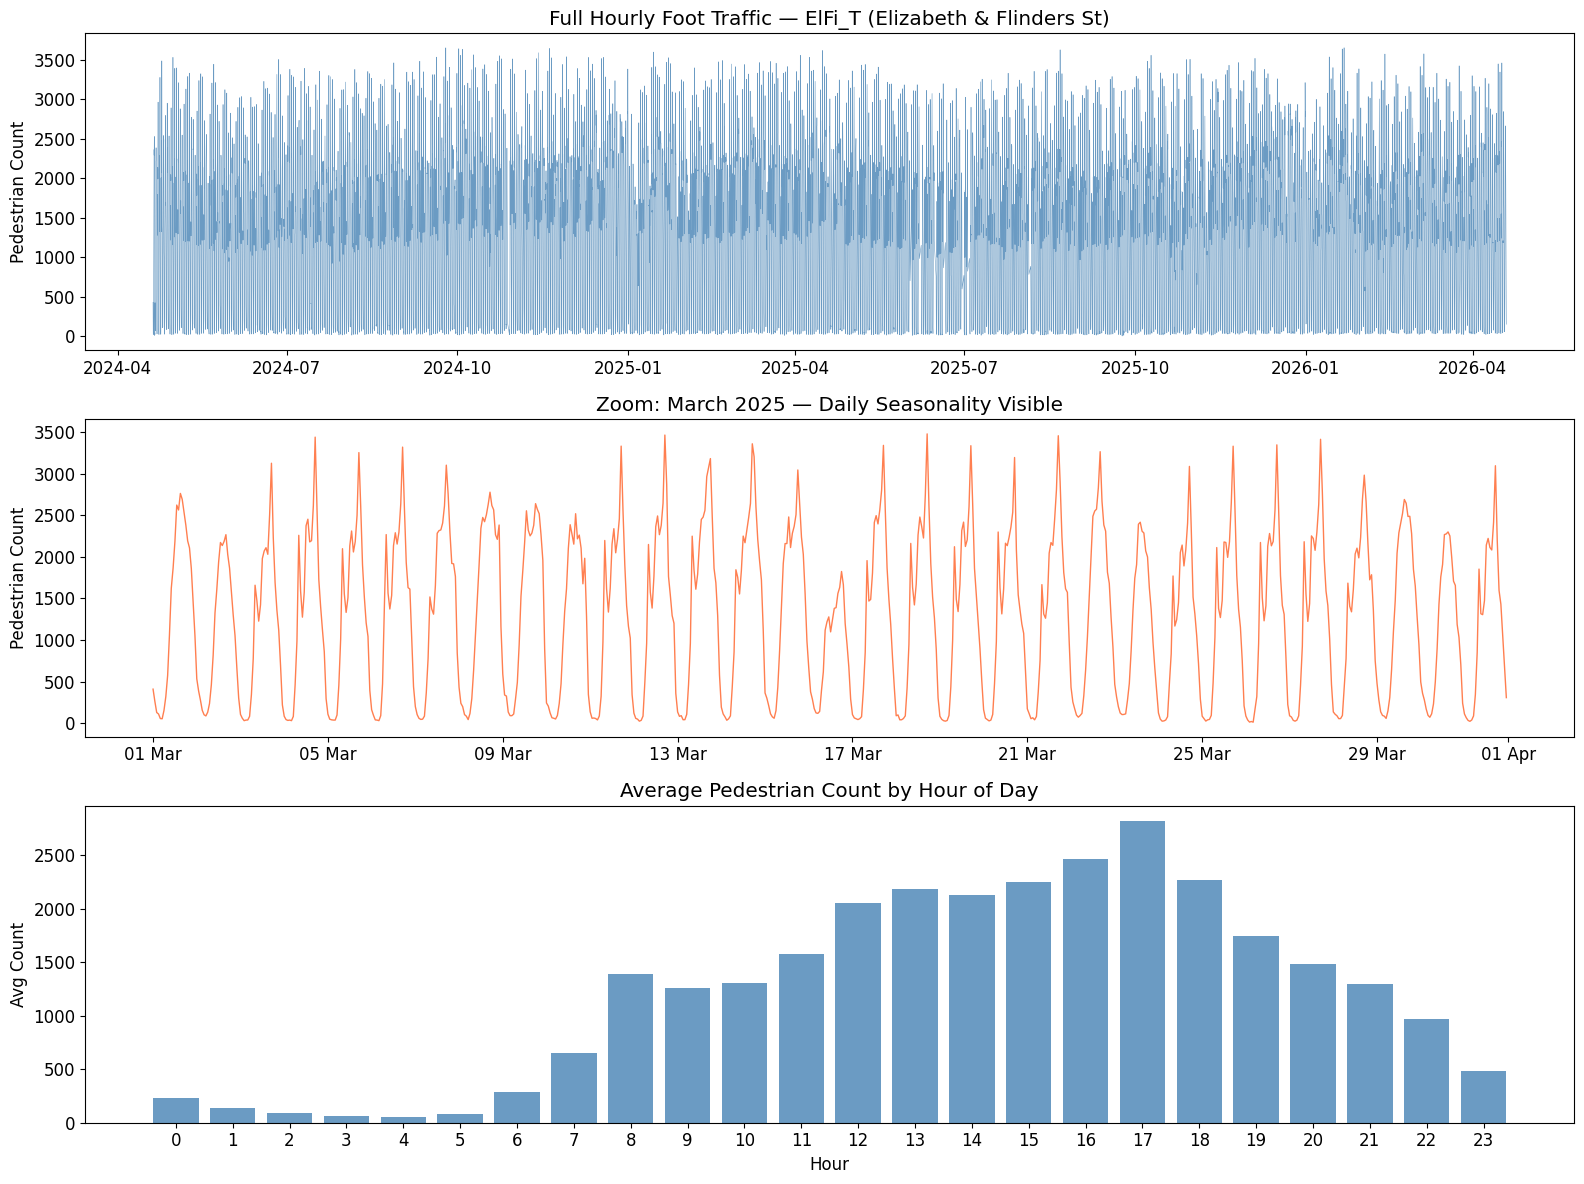

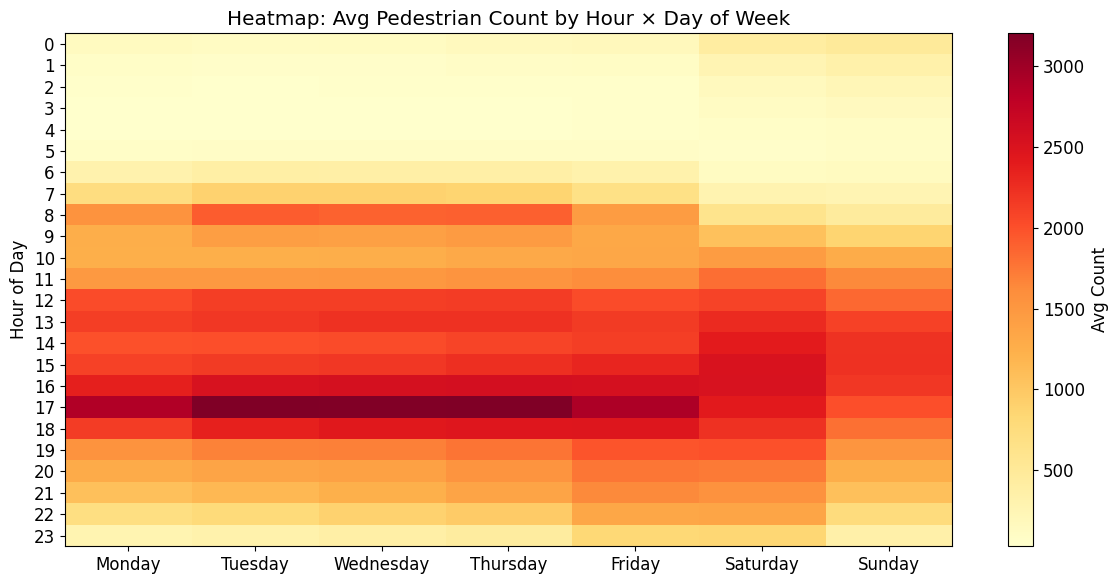

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# ── Full time series ───────────────────────────────────────────────────────
axes[0].plot(df['ds'], df['y'], linewidth=0.4, color='steelblue', alpha=0.8)
axes[0].set_title(f'Full Hourly Foot Traffic — {TARGET_SENSOR} (Elizabeth & Flinders St)')
axes[0].set_ylabel('Pedestrian Count')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# ── Zoom in on one month to see daily pattern ──────────────────────────────
one_month = df[(df['ds'] >= '2025-03-01') & (df['ds'] < '2025-04-01')]
axes[1].plot(one_month['ds'], one_month['y'], linewidth=1, color='coral')
axes[1].set_title('Zoom: March 2025 — Daily Seasonality Visible')
axes[1].set_ylabel('Pedestrian Count')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# ── Average by hour of day ─────────────────────────────────────────────────
df['hour'] = df['ds'].dt.hour
df['dayofweek'] = df['ds'].dt.day_name()

hourly_avg = df.groupby('hour')['y'].mean()
axes[2].bar(hourly_avg.index, hourly_avg.values, color='steelblue', alpha=0.8)
axes[2].set_title('Average Pedestrian Count by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Avg Count')
axes[2].set_xticks(range(24))

plt.tight_layout()
plt.show()

# ── Weekly heatmap ─────────────────────────────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.pivot_table(values='y', index='hour', columns='dayofweek', aggfunc='mean')
pivot = pivot[day_order]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(7))
ax.set_xticklabels(day_order)
ax.set_yticks(range(24))
ax.set_yticklabels(range(24))
ax.set_title('Heatmap: Avg Pedestrian Count by Hour × Day of Week')
ax.set_ylabel('Hour of Day')
plt.colorbar(im, ax=ax, label='Avg Count')
plt.tight_layout()
plt.show()

## Cell 7 — Stationarity Test (ADF Test for SARIMA)

Aplicamos el test de estacioneriedad de Dickey-Fuller para determinar los hiperparametros adecuados para SARIMA.

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -13.5367
p-value       : 0.0000
Critical Values:
   1%: -3.4307
   5%: -2.8617
   10%: -2.5669
Series is STATIONARY (p < 0.05) -> d=0


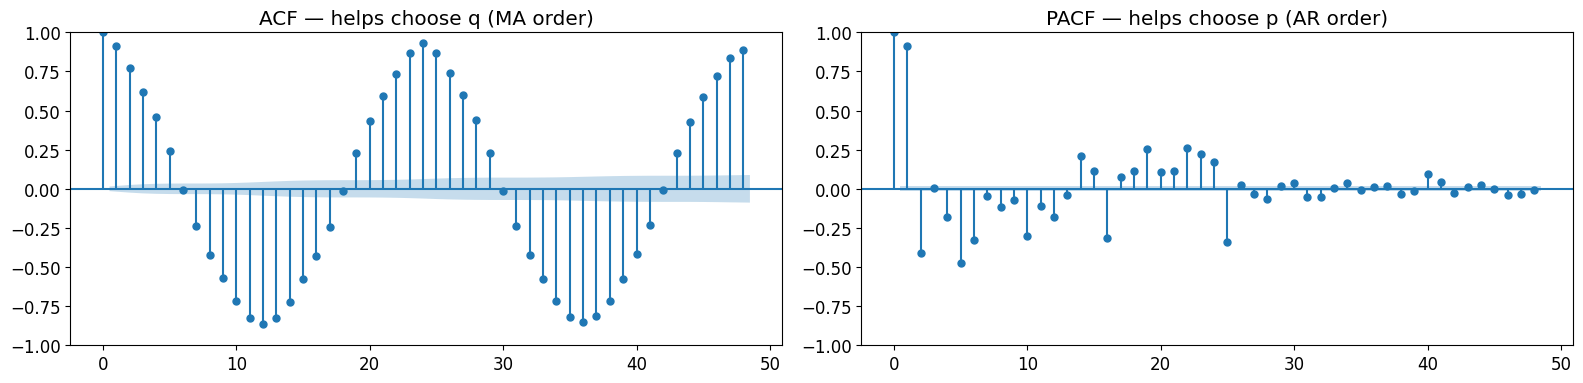

In [37]:
# Augmented Dickey-Fuller test

result = adfuller(df['y'].dropna())

print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print(f'Critical Values:')
for key, val in result[4].items():
    print(f'   {key}: {val:.4f}')

if result[1] < 0.05:
    print('Series is STATIONARY (p < 0.05) -> d=0')
else:
    print('Series is NON-STATIONARY (p >= 0.05) -> d=1')

# ACF / PACF plots
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['y'].dropna(), lags=48, ax=axes[0])
axes[0].set_title('ACF — helps choose q (MA order)')
plot_pacf(df['y'].dropna(), lags=48, ax=axes[1])
axes[1].set_title('PACF — helps choose p (AR order)')
plt.tight_layout()
plt.show()

## Cell 8 — Train / Test Split

Dividimos los datos entre el set de entrenamiento y el set de validación. Se utiliza una ventana de 1 año para el set de entrenamiento y una ventana de una semana para la validación.

Train: 8,760 hours  (2025-03-15 → 2026-03-21)
Test:  672 hours   (2026-03-21 → 2026-04-19)


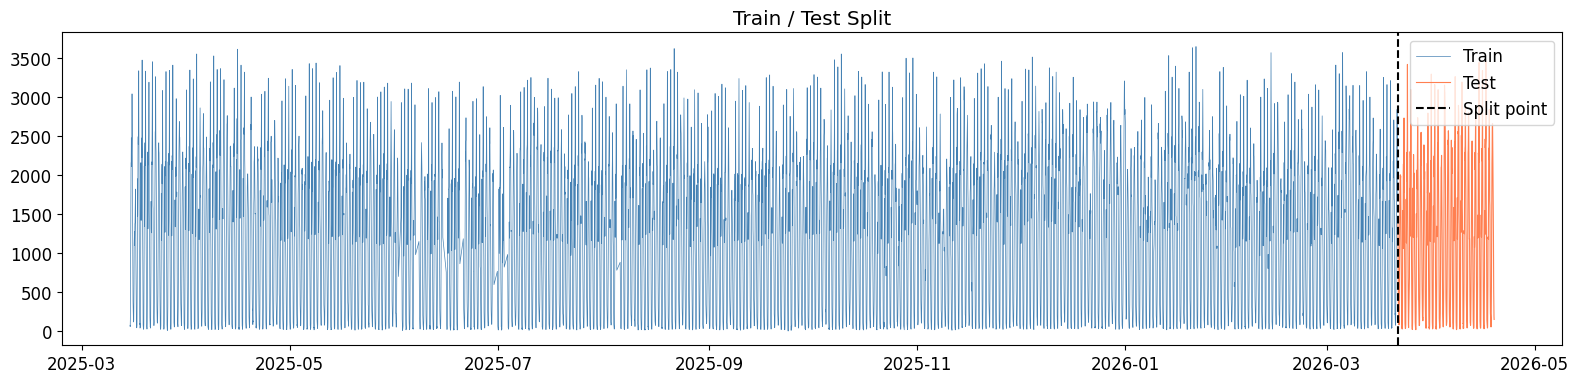

In [38]:
TEST_HOURS  = 24 * 7 * 4   # 4 weeks test
TRAIN_HOURS = 24 * 365     # 1 year train — enough for SARIMA, saves RAM

df_model = df.iloc[-(TRAIN_HOURS + TEST_HOURS):].copy().reset_index(drop=True)

train = df_model.iloc[:-TEST_HOURS].copy()
test  = df_model.iloc[-TEST_HOURS:].copy()

print(f'Train: {len(train):,} hours  ({train["ds"].min().date()} → {train["ds"].max().date()})')
print(f'Test:  {len(test):,} hours   ({test["ds"].min().date()} → {test["ds"].max().date()})')

plt.figure(figsize=(16, 4))
plt.plot(train['ds'], train['y'], label='Train', color='steelblue', linewidth=0.5)
plt.plot(test['ds'],  test['y'],  label='Test',  color='coral',     linewidth=0.8)
plt.axvline(test['ds'].min(), color='black', linestyle='--', label='Split point')
plt.title('Train / Test Split')
plt.legend()
plt.tight_layout()
plt.show()

## Cell 9 — Auto-SARIMA


In [39]:
# p=1
# d=1
# q=1
# P,D,Q=1,1,1 for (24h) cycle

print('Fitting SARIMA(1,1,1)(1,1,1)[24] ...')

sarima_model = SARIMAX(
    train['y'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

auto_model = sarima_model.fit(disp=False, maxiter=50)

print('SARIMA fitted')
print(auto_model.summary())

Fitting SARIMA(1,1,1)(1,1,1)[24] ...
SARIMA fitted
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 8760
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -58997.570
Date:                            Sun, 19 Apr 2026   AIC                         118005.140
Time:                                    19:43:32   BIC                         118040.501
Sample:                                         0   HQIC                        118017.192
                                           - 8760                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7368      0.006    122.528      0.000       0.

## Cell 10 — SARIMA Forecast & Evaluation

Realizamos una predicción con SARIMA y comparamos con los valores actuales del dataset para calcular las métricas. Luego procedemos a realizar el mismo proceso con Prophet para calcular ambos metodos.

=== SARIMA Results ===
MAE:   976.4
RMSE:  1151.8
MAPE:  440.5%


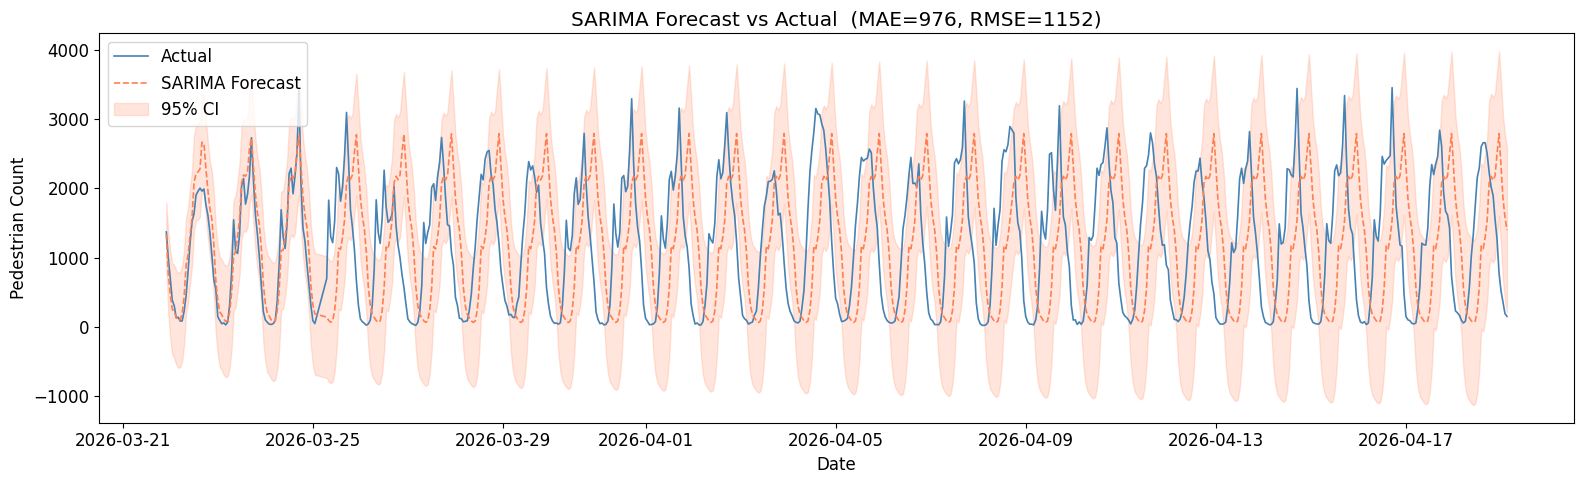

In [40]:
# Forecast test period
sarima_forecast = auto_model.get_forecast(steps=len(test))
sarima_pred     = np.clip(sarima_forecast.predicted_mean.values, 0, None)
conf_int        = sarima_forecast.conf_int().values

y_true = test['y'].values

sarima_mae  = mean_absolute_error(y_true, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(y_true, sarima_pred))
sarima_mape = np.mean(np.abs((y_true - sarima_pred) / np.where(y_true == 0, 1, y_true))) * 100

print('=== SARIMA Results ===')
print(f'MAE:   {sarima_mae:.1f}')
print(f'RMSE:  {sarima_rmse:.1f}')
print(f'MAPE:  {sarima_mape:.1f}%')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test['ds'].values, y_true,      label='Actual',          color='steelblue', linewidth=1.2)
ax.plot(test['ds'].values, sarima_pred, label='SARIMA Forecast', color='coral',     linewidth=1.2, linestyle='--')
ax.fill_between(test['ds'].values, conf_int[:, 0], conf_int[:, 1], alpha=0.2, color='coral', label='95% CI')
ax.set_title(f'SARIMA Forecast vs Actual  (MAE={sarima_mae:.0f}, RMSE={sarima_rmse:.0f})')
ax.set_xlabel('Date')
ax.set_ylabel('Pedestrian Count')
ax.legend()
plt.tight_layout()
plt.show()

## Cell 11 — Prophet: Fit & Forecast

In [41]:
prophet_model = Prophet(
    seasonality_mode='multiplicative',  # amplitude of seasonality scales with trend
    daily_seasonality=True,             # captures the daily cycle
    weekly_seasonality=True,            # captures weekly pattern
    yearly_seasonality=True,            # captures annual trends
    interval_width=0.95,                # 95% confidence interval
    changepoint_prior_scale=0.05,       # trend flexibility
)

# Adds Australian public holidays — affects Melbourne foot traffic significantly
prophet_model.add_country_holidays(country_name='AU')

print('Fitting Prophet...')
prophet_model.fit(train[['ds', 'y']])
print('Prophet fitted')

# Build future dataframe that covers the test period
future = prophet_model.make_future_dataframe(periods=len(test), freq='H')
forecast = prophet_model.predict(future)

# Extract only test period predictions
prophet_test = forecast.tail(len(test)).copy()
prophet_pred = np.clip(prophet_test['yhat'].values, 0, None)

Fitting Prophet...
Prophet fitted


## Cell 12 — Prophet Evaluation & Plots

=== Prophet Results ===
MAE:   930.4 pedestrians
RMSE:  1088.1 pedestrians
MAPE:  392.4%


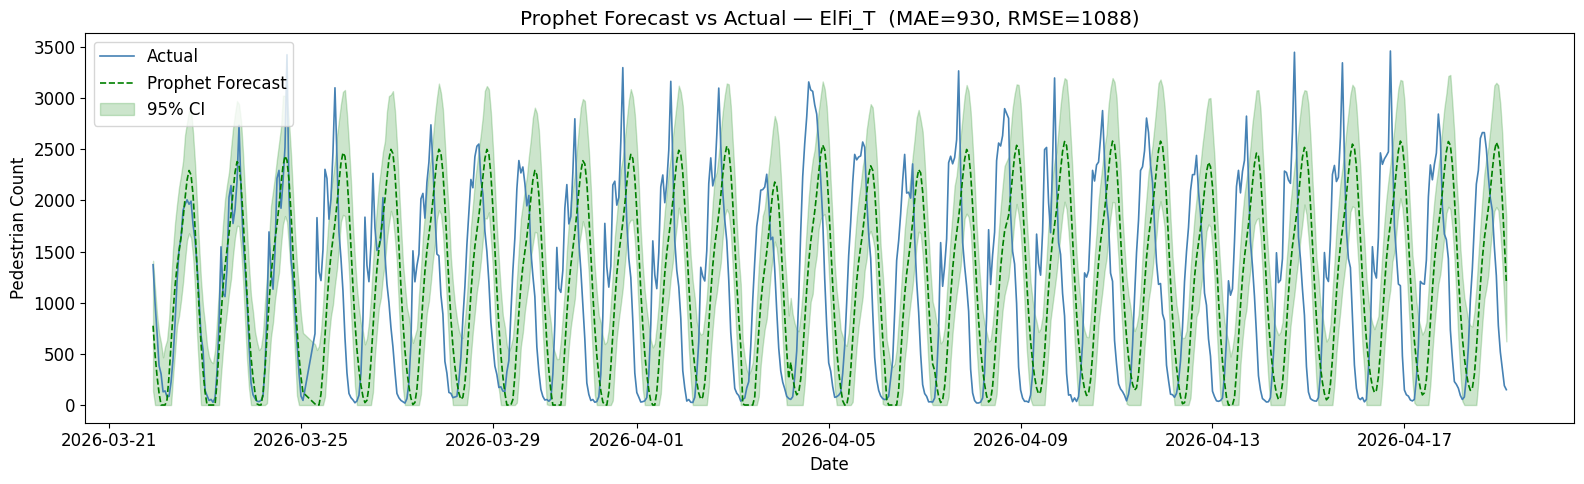

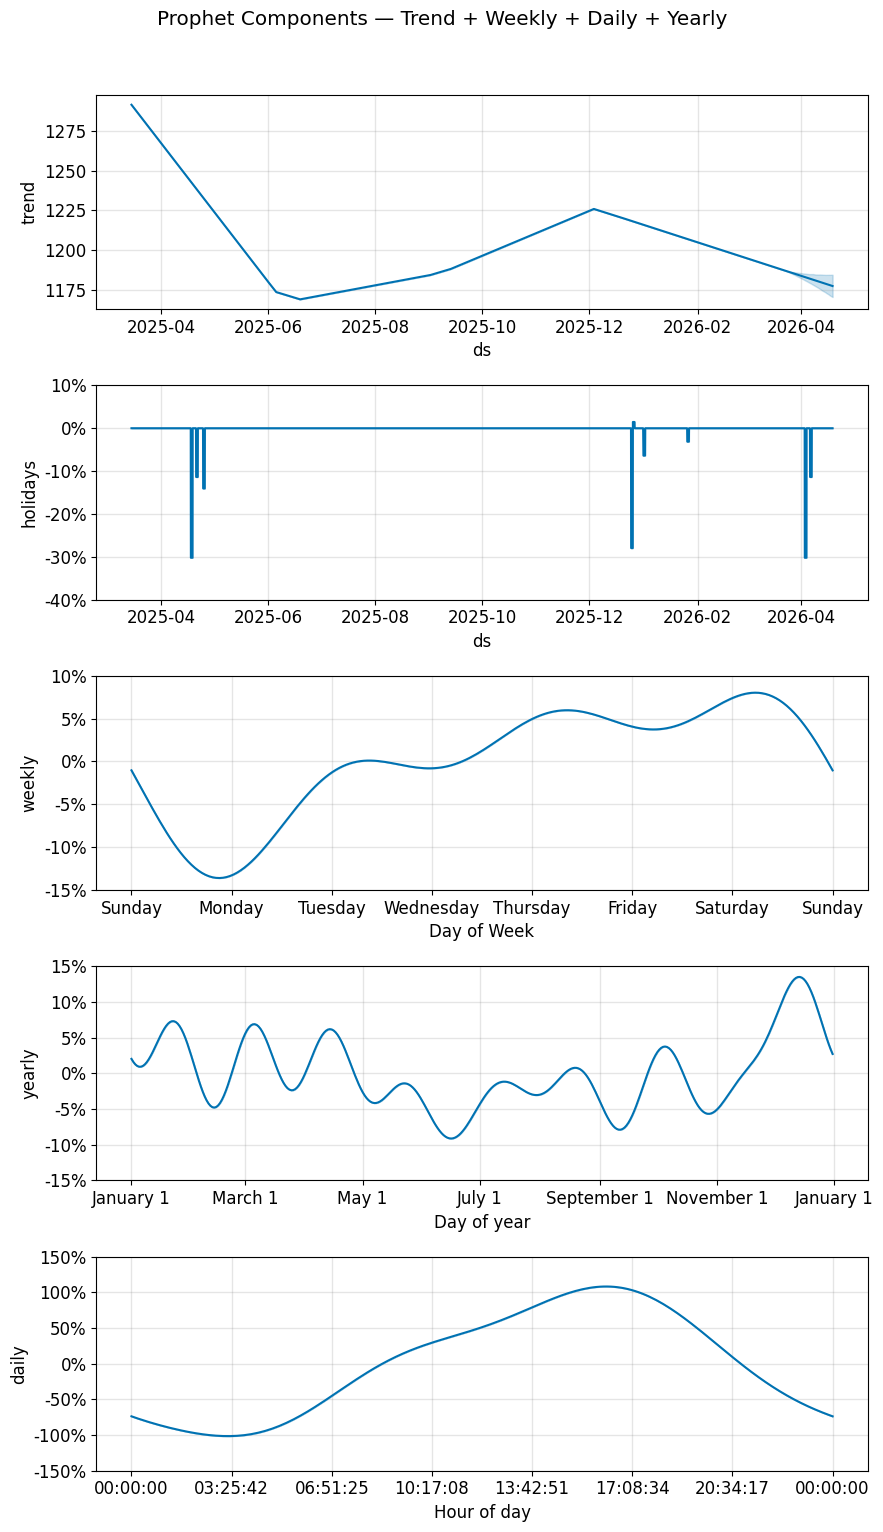

In [42]:
# ── Metrics ────────────────────────────────────────────────────────────────
prophet_mae  = mean_absolute_error(y_true, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(y_true, prophet_pred))
prophet_mape = np.mean(np.abs((y_true - prophet_pred) / np.where(y_true == 0, 1, y_true))) * 100

print('=== Prophet Results ===')
print(f'MAE:   {prophet_mae:.1f} pedestrians')
print(f'RMSE:  {prophet_rmse:.1f} pedestrians')
print(f'MAPE:  {prophet_mape:.1f}%')

# ── Forecast plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test['ds'].values, y_true,       label='Actual',           color='steelblue', linewidth=1.2)
ax.plot(test['ds'].values, prophet_pred, label='Prophet Forecast', color='green',     linewidth=1.2, linestyle='--')
ax.fill_between(
    test['ds'].values,
    np.clip(prophet_test['yhat_lower'].values, 0, None),
    prophet_test['yhat_upper'].values,
    alpha=0.2, color='green', label='95% CI'
)
ax.set_title(f'Prophet Forecast vs Actual — {TARGET_SENSOR}  (MAE={prophet_mae:.0f}, RMSE={prophet_rmse:.0f})')
ax.set_xlabel('Date')
ax.set_ylabel('Pedestrian Count')
ax.legend()
plt.tight_layout()
plt.show()

# ── Component decomposition ─────────────────────
fig = prophet_model.plot_components(forecast)
plt.suptitle('Prophet Components — Trend + Weekly + Daily + Yearly', y=1.02)
plt.tight_layout()
plt.show()

## Cell 13 — Final Comparison: SARIMA vs Prophet

De los resultados anteriores comparamos ambos metodos para verificar si los componentes estacionarios adicionales que Prophet alcanza a capturar mejoran la precisión de la predicción en comparación con SARIMA.



=== Baseline Model Comparison ===
  Model   MAE   RMSE  MAPE %
 SARIMA 976.4 1151.8  440.49
Prophet 930.4 1088.1  392.39


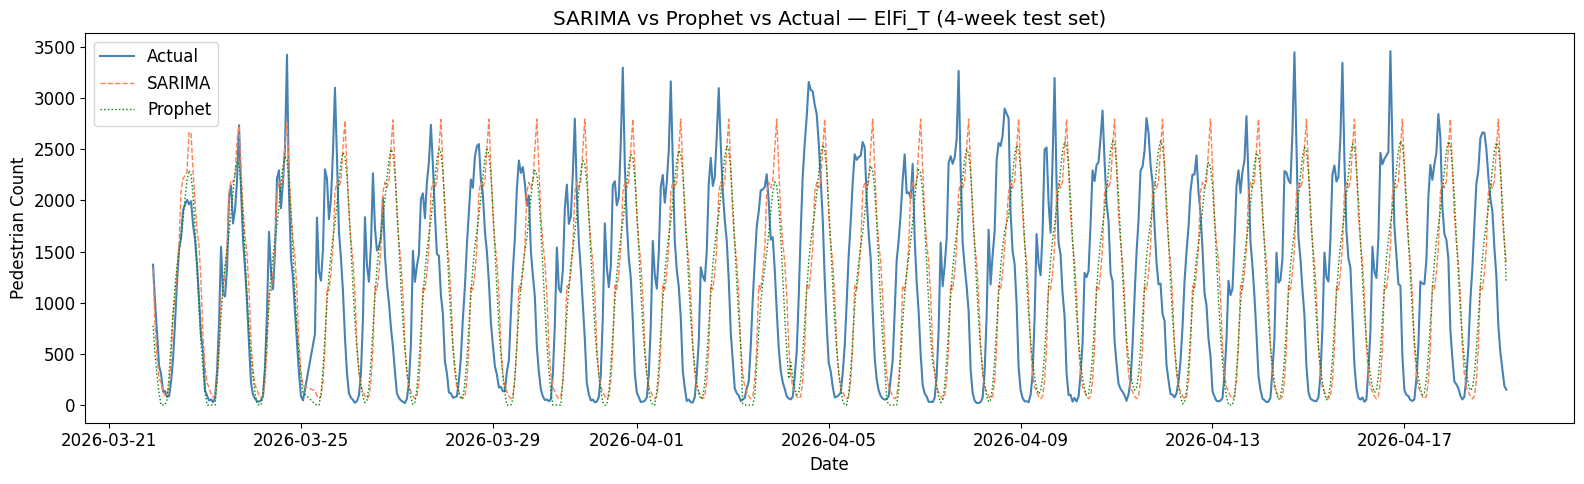

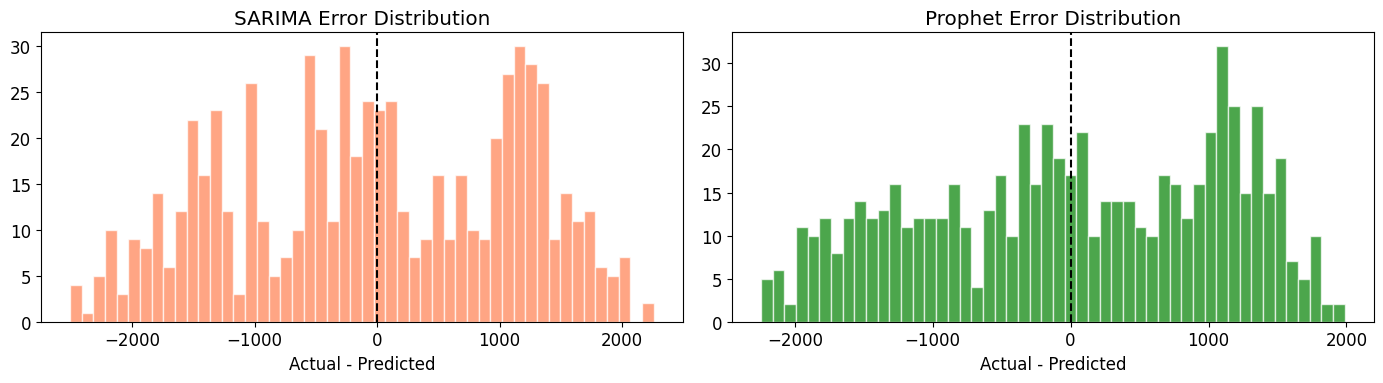

In [43]:
# ── Side-by-side metrics table ─────────────────────────────────────────────
results = pd.DataFrame({
    'Model':  ['SARIMA', 'Prophet'],
    'MAE':    [round(sarima_mae,  1), round(prophet_mae,  1)],
    'RMSE':   [round(sarima_rmse, 1), round(prophet_rmse, 1)],
    'MAPE %': [round(sarima_mape, 2), round(prophet_mape, 2)],
})
print('=== Baseline Model Comparison ===')
print(results.to_string(index=False))

# ── Overlay both forecasts vs actual ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test['ds'].values, y_true,       label='Actual',           color='steelblue', linewidth=1.5)
ax.plot(test['ds'].values, sarima_pred,  label='SARIMA',           color='coral',     linewidth=1,   linestyle='--')
ax.plot(test['ds'].values, prophet_pred, label='Prophet',          color='green',     linewidth=1,   linestyle=':')
ax.set_title(f'SARIMA vs Prophet vs Actual — {TARGET_SENSOR} (4-week test set)')
ax.set_xlabel('Date')
ax.set_ylabel('Pedestrian Count')
ax.legend()
plt.tight_layout()
plt.show()

# ── Error distribution ─────────────────────────────────────────────────────
sarima_err  = y_true - sarima_pred
prophet_err = y_true - prophet_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sarima_err,  bins=50, color='coral',  alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('SARIMA Error Distribution')
axes[0].set_xlabel('Actual - Predicted')

axes[1].hist(prophet_err, bins=50, color='green',  alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Prophet Error Distribution')
axes[1].set_xlabel('Actual - Predicted')

plt.tight_layout()
plt.show()

## Cell 14 — Transformer Imports & Hyperparameters

In [44]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Vanilla hyperparameters ───────────────────────────────────────────────────
SEQ_LEN_V  = 168        # 1 week of context
HORIZON_V  = len(test)  # predict entire test set in one shot
BATCH_V    = 64
EPOCHS_V   = 100
LR_V       = 1e-4
D_MODEL_V  = 64
N_HEADS_V  = 4
N_LAYERS_V = 2
D_FF_V     = 256
DROPOUT_V  = 0.1

print(f'Device: {DEVICE}')
print(f'SEQ_LEN={SEQ_LEN_V}h  HORIZON={HORIZON_V}h  d_model={D_MODEL_V}')

Device: cuda
SEQ_LEN=168h  HORIZON=672h  d_model=64


## Cell 15 — Scale Data & Build Sliding-Window Dataset

Definimos las ventanas y el horizonte de predicción.

In [45]:
# ── Scale ─────────────────────────────────────────────────────────────────────
scaler_v = MinMaxScaler()
train_vals_v = scaler_v.fit_transform(train['y'].values.reshape(-1,1)).flatten()
test_vals_v  = scaler_v.transform(test['y'].values.reshape(-1,1)).flatten()

# ── Sliding window dataset ────────────────────────────────────────────────────
class DirectDataset(Dataset):
    def __init__(self, series, seq_len, horizon):
        self.X, self.y = [], []
        for i in range(len(series) - seq_len - horizon + 1):
            self.X.append(series[i : i + seq_len])
            self.y.append(series[i + seq_len : i + seq_len + horizon])
        self.X = torch.tensor(self.X, dtype=torch.float32).unsqueeze(-1)  # (N, seq_len, 1)
        self.y = torch.tensor(self.y, dtype=torch.float32)                 # (N, horizon)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

dataset_v = DirectDataset(train_vals_v, SEQ_LEN_V, HORIZON_V)
loader_v  = DataLoader(dataset_v, batch_size=BATCH_V, shuffle=True, drop_last=False)

print(f'Dataset: {len(dataset_v):,} windows  |  X:({SEQ_LEN_V},1)  y:({HORIZON_V},)')

Dataset: 7,921 windows  |  X:(168,1)  y:(672,)


## Cell 16 — Vanilla Transformer Model

Definimos nuestro Transformer inicial con la arquitectura tradicional Encoder-Decoder de Vaswani et Al.

In [46]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class EncoderDecoderTransformer(nn.Module):
    """
    Canonical Transformer with encoder + decoder.
    """
    def __init__(self, in_features, out_features, horizon,
                 d_model=64, n_heads=4, n_layers=2, d_ff=256, dropout=0.1):
        super().__init__()
        self.horizon     = horizon
        self.out_features = out_features

        # ── Encoder side ──────────────────────────────────────────────────────
        self.enc_input_proj = nn.Linear(in_features, d_model)
        self.enc_pos_enc    = PositionalEncoding(d_model, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # ── Decoder side ──────────────────────────────────────────────────────
        self.query_embed = nn.Embedding(horizon, d_model)
        self.dec_pos_enc = PositionalEncoding(d_model, dropout=dropout)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_layers)

        # ── Output projection ─────────────────────────────────────────────────
        self.output_proj = nn.Linear(d_model, out_features)

    def forward(self, src):
        # src: (B, seq_len, in_features)
        B = src.size(0)

        # ── Encode historical sequence ────────────────────────────────────────
        enc = self.enc_input_proj(src)   # (B, seq_len, d_model)
        enc = self.enc_pos_enc(enc)      # add positional info
        memory = self.encoder(enc)       # (B, seq_len, d_model)

        # ── Build decoder queries ─────────────────────────────────────────────
        query_ids = torch.arange(self.horizon, device=src.device)          # (horizon,)
        queries   = self.query_embed(query_ids)                             # (horizon, d_model)
        queries   = queries.unsqueeze(0).expand(B, -1, -1)                 # (B, horizon, d_model)
        queries   = self.dec_pos_enc(queries)  # add positional info to queries

        # ── Decode: cross-attend over memory ─────────────────────────────────
        dec_out = self.decoder(queries, memory)  # (B, horizon, d_model)

        # ── Project to output space ───────────────────────────────────────────
        out = self.output_proj(dec_out)          # (B, horizon, out_features)
        return out.squeeze(-1)                   # (B, horizon)  if out_features=1


model_v = EncoderDecoderTransformer(
    in_features=1, out_features=1, horizon=HORIZON_V,
    d_model=D_MODEL_V, n_heads=N_HEADS_V, n_layers=N_LAYERS_V,
    d_ff=D_FF_V, dropout=DROPOUT_V
).to(DEVICE)
nn.init.normal_(model_v.query_embed.weight, mean=0, std=0.1)

n_params_v = sum(p.numel() for p in model_v.parameters() if p.requires_grad)
print(f' Encoder-Decoder Transformer (Vanilla) ready')
print(f'   Trainable parameters: {n_params_v:,}')
print(model_v)

 Encoder-Decoder Transformer (Vanilla) ready
   Trainable parameters: 276,673
EncoderDecoderTransformer(
  (enc_input_proj): Linear(in_features=1, out_features=64, bias=True)
  (enc_pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (query_embed): Embedding(672, 64)
  (d

## Cell 17 — Training Loop

Entrenamos nuestro modelo con el optimizador Adam a 100 Epochs.

Epoch  10/100  —  Loss: 0.063553
Epoch  20/100  —  Loss: 0.063176
Epoch  30/100  —  Loss: 0.022221
Epoch  40/100  —  Loss: 0.019111
Epoch  50/100  —  Loss: 0.017909
Epoch  60/100  —  Loss: 0.016980
Epoch  70/100  —  Loss: 0.015912
Epoch  80/100  —  Loss: 0.015203
Epoch  90/100  —  Loss: 0.014348
Epoch 100/100  —  Loss: 0.014176


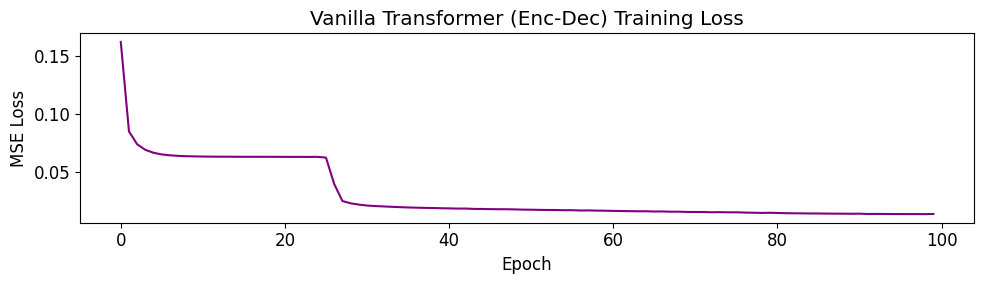

Training complete!


In [47]:
optimizer_v    = torch.optim.Adam(model_v.parameters(), lr=LR_V)
scheduler_v    = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_v, max_lr=1e-3,
    steps_per_epoch=len(loader_v), epochs=EPOCHS_V
)
criterion_v    = nn.MSELoss()
train_losses_v = []

model_v.train()
for epoch in range(1, EPOCHS_V + 1):
    epoch_loss = 0.0
    for xb, yb in loader_v:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_v.zero_grad()
        pred = model_v(xb)
        loss = criterion_v(pred, yb)
        loss.backward()
        optimizer_v.step()
        scheduler_v.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(loader_v)
    train_losses_v.append(avg)
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3}/{EPOCHS_V}  —  Loss: {avg:.6f}')

plt.figure(figsize=(10,3))
plt.plot(train_losses_v, color='purple', linewidth=1.5)
plt.title('Vanilla Transformer (Enc-Dec) Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()
print('Training complete!')

## Cell 18 — Recursive Inference on Test Set

=== Vanilla Transformer (Enc-Dec) Results ===
MAE:   916.5
RMSE:  1074.0
MAPE:  463.7%


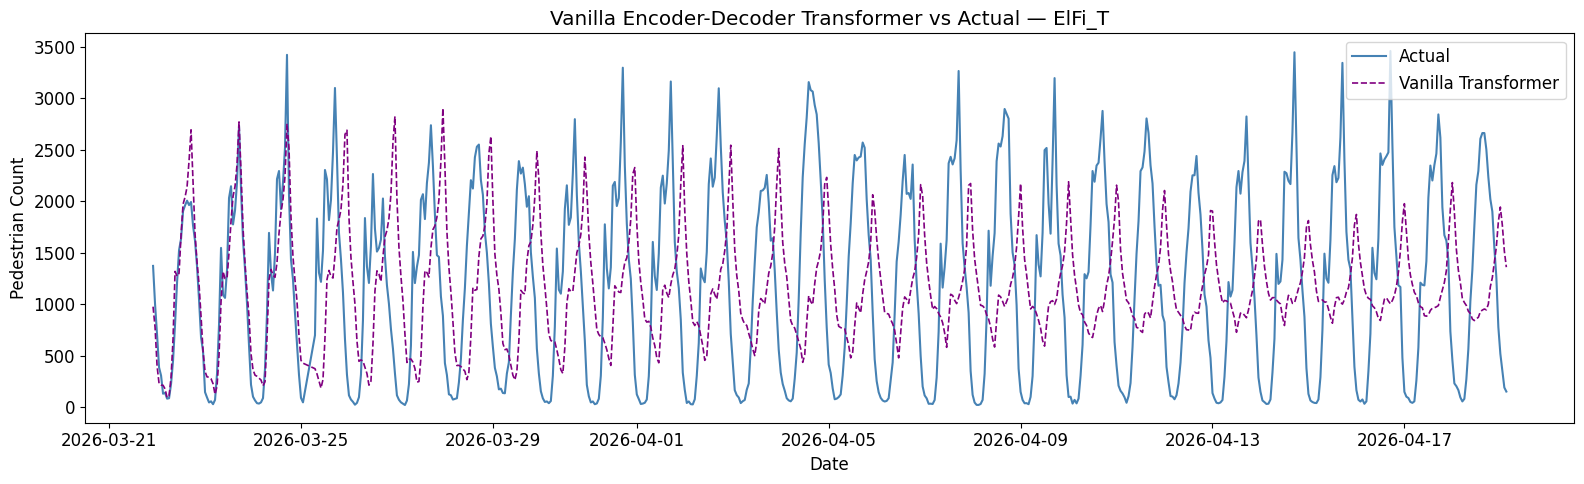

In [48]:
model_v.eval()
input_v = (
    torch.tensor(train_vals_v[-SEQ_LEN_V:], dtype=torch.float32)
    .unsqueeze(0).unsqueeze(-1).to(DEVICE)   # (1, seq_len, 1)
)
with torch.no_grad():
    vanilla_pred_scaled = model_v(input_v).squeeze(0).cpu().numpy()  # (horizon,)

vanilla_pred = np.clip(
    scaler_v.inverse_transform(vanilla_pred_scaled.reshape(-1,1)).flatten(), 0, None
)

y_true = test['y'].values
vanilla_mae  = mean_absolute_error(y_true, vanilla_pred)
vanilla_rmse = np.sqrt(mean_squared_error(y_true, vanilla_pred))
vanilla_mape = np.mean(np.abs((y_true - vanilla_pred) / np.where(y_true==0,1,y_true))) * 100

print('=== Vanilla Transformer (Enc-Dec) Results ===')
print(f'MAE:   {vanilla_mae:.1f}')
print(f'RMSE:  {vanilla_rmse:.1f}')
print(f'MAPE:  {vanilla_mape:.1f}%')

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(test['ds'].values, y_true,        label='Actual',             color='steelblue', linewidth=1.5)
ax.plot(test['ds'].values, vanilla_pred,  label='Vanilla Transformer',color='purple',    linewidth=1.2, linestyle='--')
ax.set_title(f'Vanilla Encoder-Decoder Transformer vs Actual — {TARGET_SENSOR}')
ax.set_xlabel('Date'); ax.set_ylabel('Pedestrian Count'); ax.legend()
plt.tight_layout(); plt.show()

## Final 3-Model Comparison

Comparamos los resultados de los modelos estadisticos clasicos con el modelo Transformer.

=== Final Model Comparison ===
              Model   MAE   RMSE  MAPE %
             SARIMA 976.4 1151.8  440.49
            Prophet 930.4 1088.1  392.39
Vanilla Transformer 916.5 1074.0  463.68


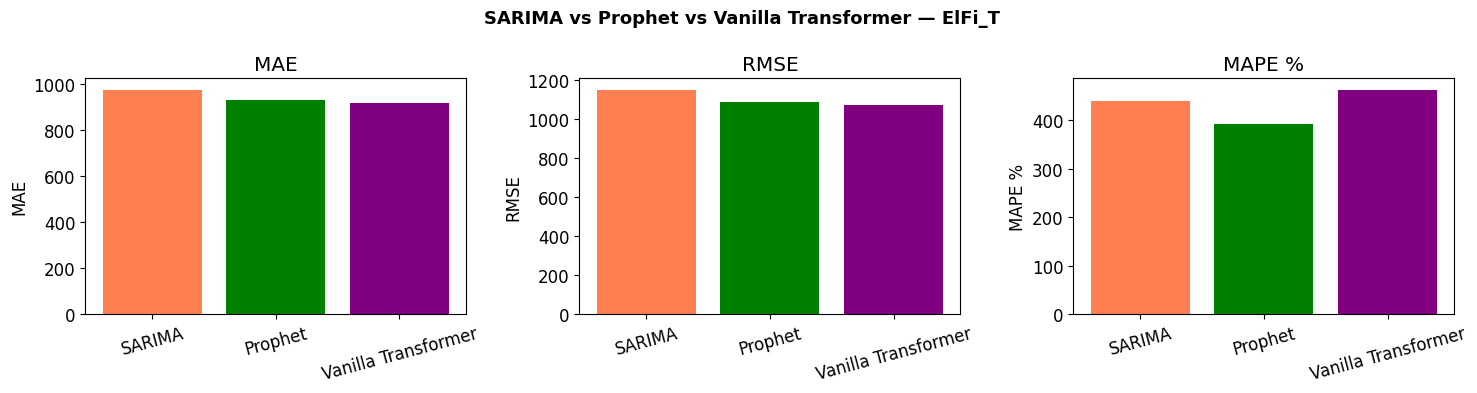

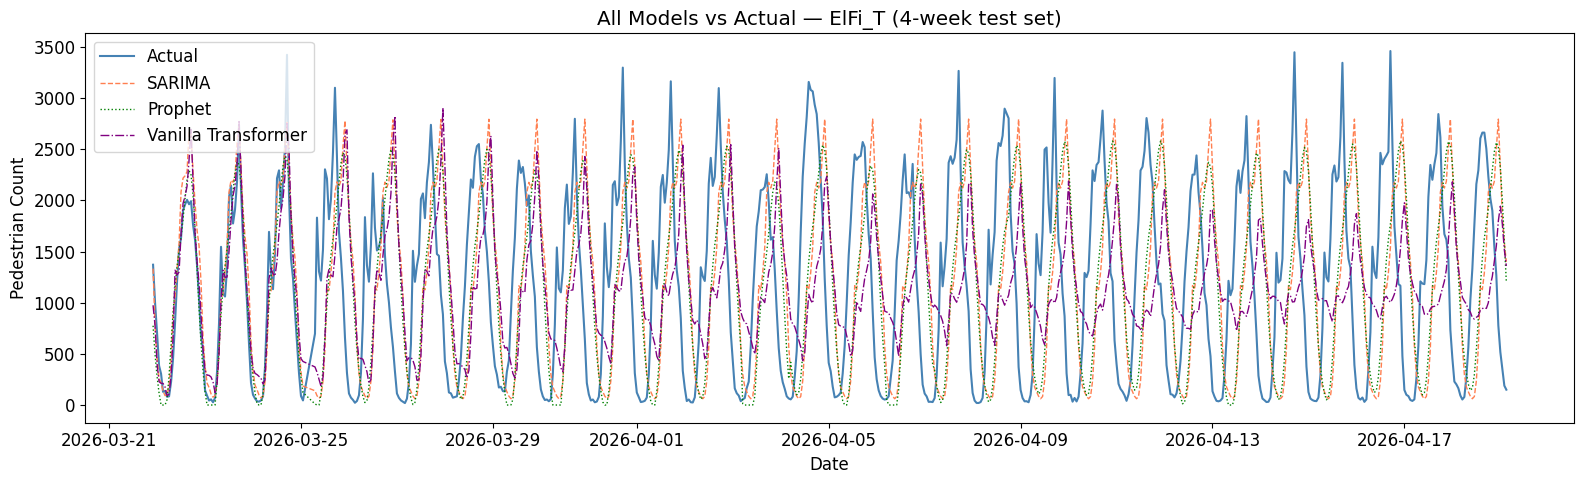

In [49]:
# ── Table ─────────────────────────────────────────────────────────────────────
results_final = pd.DataFrame({
    'Model':  ['SARIMA', 'Prophet', 'Vanilla Transformer'],
    'MAE':    [round(sarima_mae,  1), round(prophet_mae,  1), round(vanilla_mae,  1)],
    'RMSE':   [round(sarima_rmse, 1), round(prophet_rmse, 1), round(vanilla_rmse, 1)],
    'MAPE %': [round(sarima_mape, 2), round(prophet_mape, 2), round(vanilla_mape, 2)],
})
print('=== Final Model Comparison ===')
print(results_final.to_string(index=False))

# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bar_colors = ['coral', 'green', 'purple']
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE %']):
    axes[i].bar(results_final['Model'], results_final[metric], color=bar_colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle(f'SARIMA vs Prophet vs Vanilla Transformer — {TARGET_SENSOR}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Overlay all three forecasts ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test['ds'].values, y_true,           label='Actual',               color='steelblue', linewidth=1.5)
ax.plot(test['ds'].values, sarima_pred,      label='SARIMA',               color='coral',     linewidth=1.0, linestyle='--')
ax.plot(test['ds'].values, prophet_pred,     label='Prophet',              color='green',     linewidth=1.0, linestyle=':')
ax.plot(test['ds'].values, vanilla_pred, label='Vanilla Transformer',  color='purple',    linewidth=1.0, linestyle='-.')
ax.set_title(f'All Models vs Actual — {TARGET_SENSOR} (4-week test set)')
ax.set_xlabel('Date')
ax.set_ylabel('Pedestrian Count')
ax.legend()
plt.tight_layout()
plt.show()

## Tuned Transformer — Direct Forecasting + 2-Week Context
Dos cambios significativos del Transformer original:

**SEQ_LEN = 336** — dos semanas completas de contexto.

**Direct multi-step forecasting** — predecimos el horizonte completo, eliminando asi el error acumulativo de la inferencia recurrente.

In [50]:
SEQ_LEN_T  = 336        # ★ 2 weeks
HORIZON_T  = len(test)
BATCH_T    = 64
EPOCHS_T   = 100
LR_T       = 1e-4
D_MODEL_T  = 64
N_HEADS_T  = 4
N_LAYERS_T = 2
D_FF_T     = 256
DROPOUT_T  = 0.1

print(f'Tuned config: SEQ_LEN={SEQ_LEN_T}h ({SEQ_LEN_T//24} days)  HORIZON={HORIZON_T}h')

Tuned config: SEQ_LEN=336h (14 days)  HORIZON=672h


## Cell T8 — Direct Forecasting Dataset

In [51]:
scaler_t     = MinMaxScaler()
train_vals_t = scaler_t.fit_transform(train['y'].values.reshape(-1,1)).flatten()

dataset_t = DirectDataset(train_vals_t, SEQ_LEN_T, HORIZON_T)
loader_t  = DataLoader(dataset_t, batch_size=BATCH_T, shuffle=True, drop_last=False)

print(f'Dataset: {len(dataset_t):,} windows  |  X:({SEQ_LEN_T},1)  y:({HORIZON_T},)')

Dataset: 7,753 windows  |  X:(336,1)  y:(672,)


## Cell T9 — Tuned Transformer Model

In [52]:
# Reuses the same EncoderDecoderTransformer class — just different SEQ_LEN
model_t = EncoderDecoderTransformer(
    in_features=1, out_features=1, horizon=HORIZON_T,
    d_model=D_MODEL_T, n_heads=N_HEADS_T, n_layers=N_LAYERS_T,
    d_ff=D_FF_T, dropout=DROPOUT_T
).to(DEVICE)

n_params_t = sum(p.numel() for p in model_t.parameters() if p.requires_grad)
print(f'Tuned Enc-Dec Transformer ready — {n_params_t:,} parameters')

Tuned Enc-Dec Transformer ready — 276,673 parameters


## Cell T10 — Training Loop (Tuned)


Epoch  10/100  —  Loss: 0.063297
Epoch  20/100  —  Loss: 0.062989
Epoch  30/100  —  Loss: 0.062954
Epoch  40/100  —  Loss: 0.020978
Epoch  50/100  —  Loss: 0.018812
Epoch  60/100  —  Loss: 0.017780
Epoch  70/100  —  Loss: 0.017232
Epoch  80/100  —  Loss: 0.016744
Epoch  90/100  —  Loss: 0.016402
Epoch 100/100  —  Loss: 0.016222


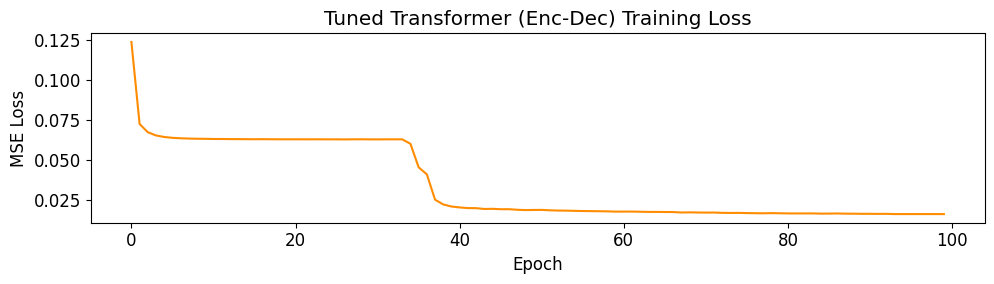

Training complete!


In [53]:
optimizer_t    = torch.optim.Adam(model_t.parameters(), lr=LR_T)
scheduler_t    = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_t, max_lr=1e-3,
    steps_per_epoch=len(loader_t), epochs=EPOCHS_T
)
criterion_t    = nn.MSELoss()
train_losses_t = []

model_t.train()
for epoch in range(1, EPOCHS_T + 1):
    epoch_loss = 0.0
    for xb, yb in loader_t:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_t.zero_grad()
        pred = model_t(xb)
        loss = criterion_t(pred, yb)
        loss.backward()
        optimizer_t.step()
        scheduler_t.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(loader_t)
    train_losses_t.append(avg)
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3}/{EPOCHS_T}  —  Loss: {avg:.6f}')

plt.figure(figsize=(10,3))
plt.plot(train_losses_t, color='darkorange', linewidth=1.5)
plt.title('Tuned Transformer (Enc-Dec) Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()
print('Training complete!')

## Cell T11 — Direct Inference (Single Forward Pass)

Aqui realizamos la inferencia directa en contraste con la inferencia recurrente realizada en los modelos anteriores.

In [54]:
model_t.eval()
input_t = (
    torch.tensor(train_vals_t[-SEQ_LEN_T:], dtype=torch.float32)
    .unsqueeze(0).unsqueeze(-1).to(DEVICE)
)
with torch.no_grad():
    tuned_pred_scaled = model_t(input_t).squeeze(0).cpu().numpy()

tuned_pred = np.clip(
    scaler_t.inverse_transform(tuned_pred_scaled.reshape(-1,1)).flatten(), 0, None
)

tuned_mae  = mean_absolute_error(y_true, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_true, tuned_pred))
tuned_mape = np.mean(np.abs((y_true - tuned_pred) / np.where(y_true==0,1,y_true))) * 100

print('=== Tuned Transformer (Enc-Dec) Results ===')
print(f'MAE:   {tuned_mae:.1f}')
print(f'RMSE:  {tuned_rmse:.1f}')
print(f'MAPE:  {tuned_mape:.1f}%')

=== Tuned Transformer (Enc-Dec) Results ===
MAE:   948.8
RMSE:  1106.2
MAPE:  422.2%


## Cell T12 — Final 4-Model Comparison

Comparamos los modelos tanto clásicos como las variaciones del Transformer.

=== Single-Sensor Comparison — ElFi_T ===
                Model   MAE   RMSE  MAPE %
               SARIMA 976.4 1151.8  440.49
              Prophet 930.4 1088.1  392.39
Transformer (Vanilla) 916.5 1074.0  463.68
  Transformer (Tuned) 948.8 1106.2  422.15


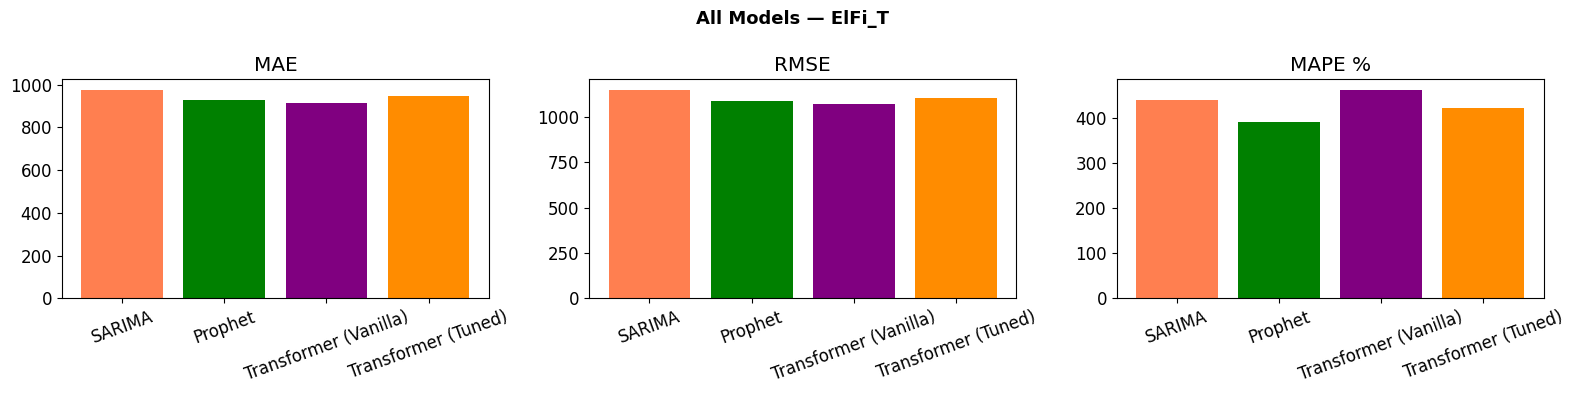

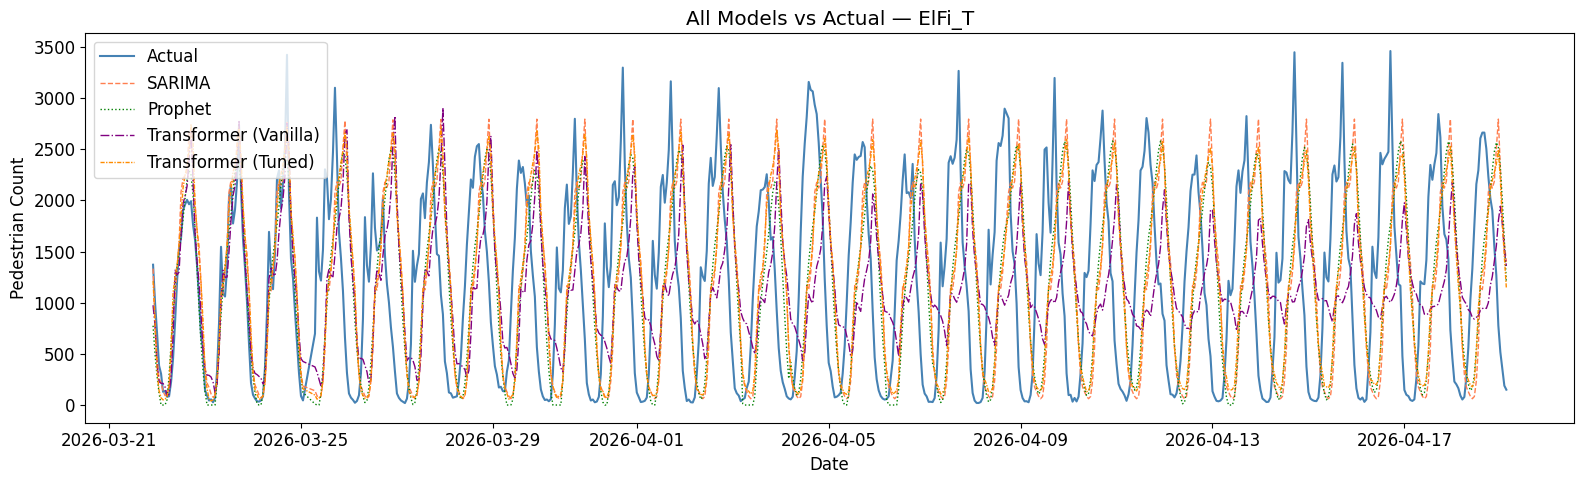

In [55]:
# ── Table ─────────────────────────────────────────────────────────────────────
results_all = pd.DataFrame({
    'Model':  ['SARIMA', 'Prophet', 'Transformer (Vanilla)', 'Transformer (Tuned)'],
    'MAE':    [round(sarima_mae,1),  round(prophet_mae,1),  round(vanilla_mae,1),  round(tuned_mae,1)],
    'RMSE':   [round(sarima_rmse,1), round(prophet_rmse,1), round(vanilla_rmse,1), round(tuned_rmse,1)],
    'MAPE %': [round(sarima_mape,2), round(prophet_mape,2), round(vanilla_mape,2), round(tuned_mape,2)],
})
print('=== Single-Sensor Comparison — ElFi_T ===')
print(results_all.to_string(index=False))

bar_colors = ['coral', 'green', 'purple', 'darkorange']
fig, axes  = plt.subplots(1, 3, figsize=(16, 4))
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE %']):
    axes[i].bar(results_all['Model'], results_all[metric], color=bar_colors)
    axes[i].set_title(metric); axes[i].tick_params(axis='x', rotation=20)
plt.suptitle(f'All Models — {TARGET_SENSOR}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Overlay all forecasts ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(test['ds'].values, y_true,       label='Actual',                color='steelblue',  linewidth=1.5)
ax.plot(test['ds'].values, sarima_pred,  label='SARIMA',                color='coral',      linewidth=1.0, linestyle='--')
ax.plot(test['ds'].values, prophet_pred, label='Prophet',               color='green',      linewidth=1.0, linestyle=':')
ax.plot(test['ds'].values, vanilla_pred, label='Transformer (Vanilla)', color='purple',     linewidth=1.0, linestyle='-.')
ax.plot(test['ds'].values, tuned_pred,   label='Transformer (Tuned)',   color='darkorange', linewidth=1.0, linestyle=(0,(3,1,1,1)))
ax.set_title(f'All Models vs Actual — {TARGET_SENSOR}')
ax.set_xlabel('Date'); ax.set_ylabel('Pedestrian Count'); ax.legend()
plt.tight_layout(); plt.show()

## Spatiotemporal Transformer — Full Sensor Network
Cambios de sensor único a red espaciotemporal:

**Input por instancia: (N_sensors,)** — Todos los sensores al tiempo y no solo uno.

El modelo aprende las relaciones entre sensores atraves de la atención.




## Cell ST1 — Build the Network Dataset

In [56]:
# ── Pivot raw data to (timestep × sensor) matrix ─────────────────────────────
raw = df_raw.copy()
raw['ds'] = pd.to_datetime(raw['Sensing_Date']) + pd.to_timedelta(raw['HourDay'], unit='h')

pivot = (
    raw.groupby(['ds','Sensor_Name'])['Total_of_Directions']
    .mean().unstack('Sensor_Name').sort_index()
)
pivot = pivot.loc['2023-01-01':'2026-01-31']

# ── Keep sensors with < 5% missing ───────────────────────────────────────────
good_sensors = pivot.columns[pivot.isnull().mean() < 0.05].tolist()
pivot        = pivot[good_sensors].interpolate(method='linear', limit=6).fillna(0)

# ── Cap at 5 sensors - Colab lmitations ─────────────────────────────────
# Pick 5 evenly spread across the list (geographic spread)
idx_5        = np.linspace(0, len(good_sensors)-1, 5, dtype=int).tolist()
sensors_5    = [good_sensors[i] for i in idx_5]
pivot        = pivot[sensors_5]
N_SENSORS_ST = len(sensors_5)

print(f'   Network dataset ready')
print(f'   Sensors selected : {sensors_5}')
print(f'   Shape            : {pivot.shape}  (timesteps × sensors)')

   Network dataset ready
   Sensors selected : ['261Will_T', 'Col623_T', 'FliSS_T', 'QVN_T', 'WestWP_T']
   Shape            : (15505, 5)  (timesteps × sensors)


## Cell ST2 — Train/Test Split + Scale

In [57]:
SEQ_LEN_ST  = 168   # 1 week
HORIZON_ST  = 168   # predict 1 week ahead
BATCH_ST    = 16
EPOCHS_ST   = 100
LR_ST       = 1e-4
D_MODEL_ST  = 64
N_HEADS_ST  = 4
N_LAYERS_ST = 2
D_FF_ST     = 256
DROPOUT_ST  = 0.1

TEST_HOURS_ST = HORIZON_ST
net_train     = pivot.iloc[:-TEST_HOURS_ST].values   # (T_train, N_sensors)
net_test      = pivot.iloc[-TEST_HOURS_ST:].values   # (horizon, N_sensors)
test_ts_st    = pivot.index[-TEST_HOURS_ST:]

net_scaler    = MinMaxScaler()
net_train_s   = net_scaler.fit_transform(net_train)
y_true_net    = net_test

print(f'  Split: train={net_train.shape}  test={net_test.shape}')

  Split: train=(15337, 5)  test=(168, 5)


## Cell ST3 — Multivariate Sliding-Window Dataset

Para esta ventana vemos como cambian de (168,1) a (168,5) debido a la cantidad de sensores utilizados.

In [58]:
class NetworkDataset(Dataset):
    """
    X: (seq_len, N_sensors)  — all sensors, historical context
    y: (horizon, N_sensors)  — all sensors, future to predict
    """
    def __init__(self, series, seq_len, horizon):
        self.X, self.y = [], []
        for i in range(len(series) - seq_len - horizon + 1):
            self.X.append(series[i : i + seq_len])
            self.y.append(series[i + seq_len : i + seq_len + horizon])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)  # (N, seq_len, N_sensors)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)  # (N, horizon, N_sensors)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

net_dataset = NetworkDataset(net_train_s, SEQ_LEN_ST, HORIZON_ST)
net_loader  = DataLoader(net_dataset, batch_size=BATCH_ST, shuffle=True, drop_last=False)

print(f'{len(net_dataset):,} windows | X:({SEQ_LEN_ST},{N_SENSORS_ST}) y:({HORIZON_ST},{N_SENSORS_ST})')

15,002 windows | X:(168,5) y:(168,5)


## Cell ST4 — Spatiotemporal Transformer


In [59]:
# Only change from single-sensor: in_features and out_features = N_SENSORS_ST
st_model = EncoderDecoderTransformer(
    in_features=N_SENSORS_ST, out_features=N_SENSORS_ST, horizon=HORIZON_ST,
    d_model=D_MODEL_ST, n_heads=N_HEADS_ST, n_layers=N_LAYERS_ST,
    d_ff=D_FF_ST, dropout=DROPOUT_ST
).to(DEVICE)

nn.init.normal_(st_model.query_embed.weight, mean=0, std=0.1)

n_params_st = sum(p.numel() for p in st_model.parameters() if p.requires_grad)
print(f'   Spatiotemporal Enc-Dec Transformer ready')
print(f'   Sensors: {N_SENSORS_ST}  |  Trainable parameters: {n_params_st:,}')

   Spatiotemporal Enc-Dec Transformer ready
   Sensors: 5  |  Trainable parameters: 244,933


##  Cell ST5 — Training

Epoch  10/100  —  Loss: 0.006449
Epoch  20/100  —  Loss: 0.003599
Epoch  30/100  —  Loss: 0.002390
Epoch  40/100  —  Loss: 0.001707
Epoch  50/100  —  Loss: 0.001296
Epoch  60/100  —  Loss: 0.001087
Epoch  70/100  —  Loss: 0.000952
Epoch  80/100  —  Loss: 0.000865
Epoch  90/100  —  Loss: 0.000825
Epoch 100/100  —  Loss: 0.000816


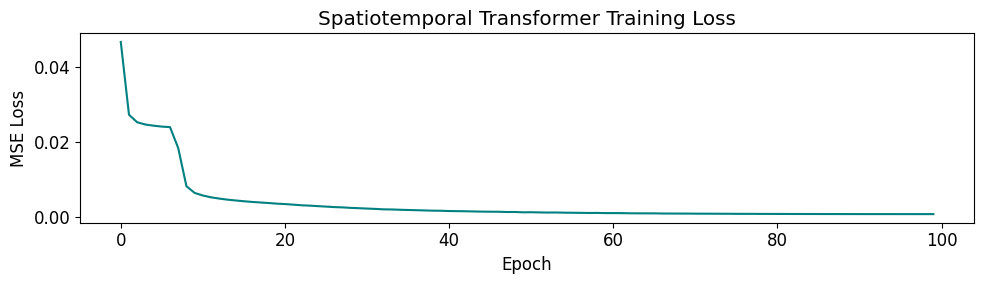

  Training complete!


In [60]:
optimizer_st    = torch.optim.Adam(st_model.parameters(), lr=LR_ST)
scheduler_st    = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_st, max_lr=1e-3,
    steps_per_epoch=len(net_loader), epochs=EPOCHS_ST
)
criterion_st    = nn.MSELoss()
train_losses_st = []

st_model.train()
for epoch in range(1, EPOCHS_ST + 1):
    epoch_loss = 0.0
    for xb, yb in net_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_st.zero_grad()
        pred = st_model(xb)
        loss = criterion_st(pred, yb)
        loss.backward()
        optimizer_st.step()
        scheduler_st.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(net_loader)
    train_losses_st.append(avg)
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3}/{EPOCHS_ST}  —  Loss: {avg:.6f}')

plt.figure(figsize=(10,3))
plt.plot(train_losses_st, color='teal', linewidth=1.5)
plt.title('Spatiotemporal Transformer Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()
print('  Training complete!')

## Cell ST6 — Inference (Spatiotemporal)

In [61]:
st_model.eval()

input_st = (
    torch.tensor(net_train_s[-SEQ_LEN_ST:], dtype=torch.float32)
    .unsqueeze(0).to(DEVICE)   # (1, seq_len, N_sensors)
)

with torch.no_grad():
    # output: (1, horizon, N_sensors)
    st_pred_scaled = st_model(input_st).squeeze(0).cpu().numpy()  # (horizon, N_sensors)

st_pred = np.clip(net_scaler.inverse_transform(st_pred_scaled), 0, None)
print(f'  Inference complete | Output shape: {st_pred.shape}')

  Inference complete | Output shape: (168, 5)


## Cell ST7 — Per-Sensor Metrics + Aggregate

In [62]:
sensor_metrics = []
for i, sensor in enumerate(sensors_5):
    yt   = y_true_net[:, i]
    yp   = st_pred[:, i]
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = np.mean(np.abs((yt - yp) / np.where(yt==0,1,yt))) * 100
    sensor_metrics.append({'Sensor': sensor, 'MAE': round(mae,1), 'RMSE': round(rmse,1), 'MAPE %': round(mape,2)})

metrics_df = pd.DataFrame(sensor_metrics)
agg        = metrics_df[['MAE','RMSE','MAPE %']].mean().round(2)

print('=== Per-Sensor Metrics — Spatiotemporal Transformer ===')
print(metrics_df.to_string(index=False))
print(f'\n=== Network-Wide Average ===')
print(f'  MAE    : {agg["MAE"]}')
print(f'  RMSE   : {agg["RMSE"]}')
print(f'  MAPE % : {agg["MAPE %"]}')

=== Per-Sensor Metrics — Spatiotemporal Transformer ===
   Sensor   MAE  RMSE  MAPE %
261Will_T  86.7 153.1   35.81
 Col623_T  66.4 108.6   31.36
  FliSS_T 150.9 252.7   26.47
    QVN_T 196.9 373.4   22.10
 WestWP_T   7.9  14.7   90.24

=== Network-Wide Average ===
  MAE    : 101.76
  RMSE   : 180.5
  MAPE % : 41.2


## Cell ST8 — Visualisation

Visualizamos las predicciónes de cada uno de los sensores y comparamos el MAPE de cada uno.

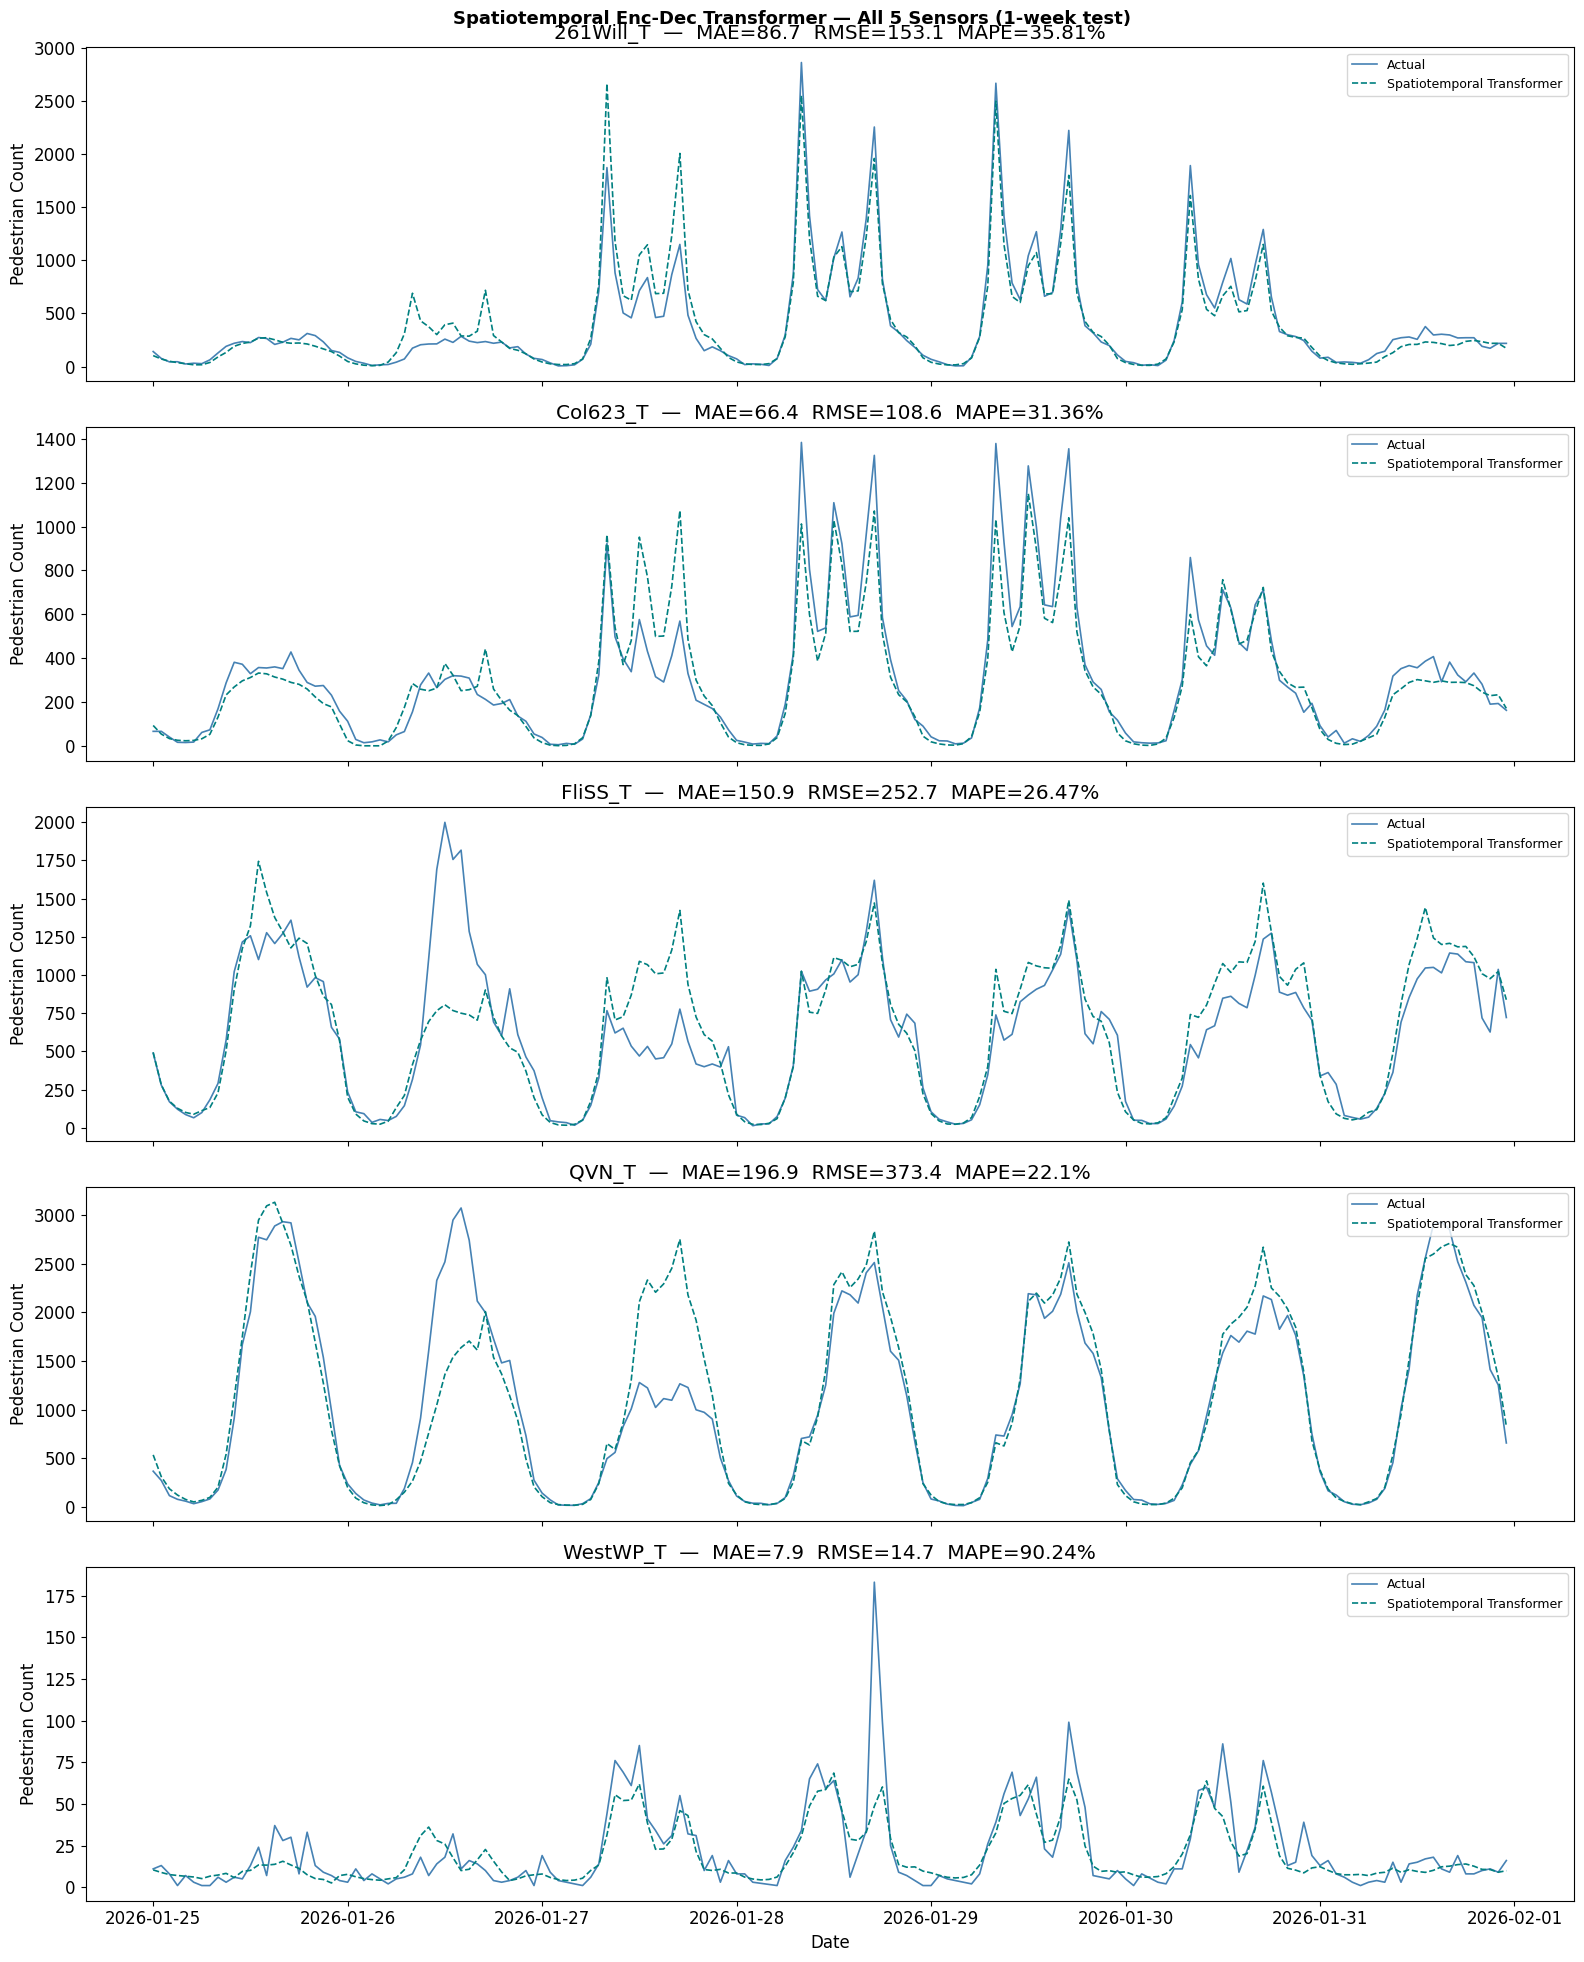

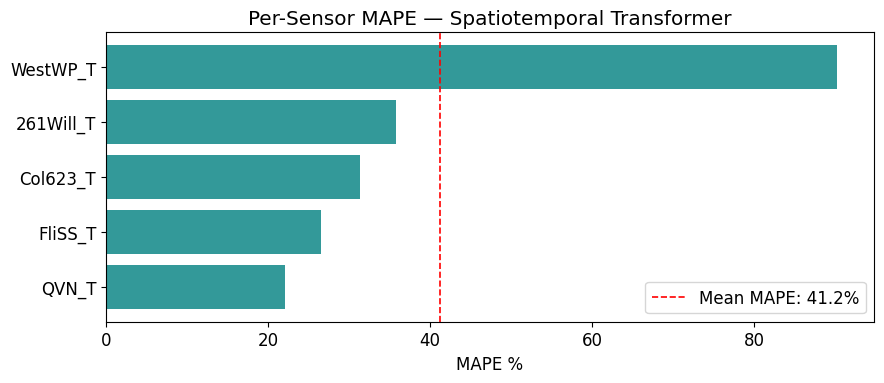

   SARIMA & Prophet: independent univariate models — no cross-sensor learning possible.
   Spatiotemporal Transformer: one unified model capturing temporal + cross-sensor dependencies.


In [63]:
# ── Forecast vs actual for all 5 sensors ──────────────────────────────────────
fig, axes = plt.subplots(N_SENSORS_ST, 1, figsize=(16, 4*N_SENSORS_ST), sharex=True)
if N_SENSORS_ST == 1: axes = [axes]

for ax, (i, sensor) in zip(axes, enumerate(sensors_5)):
    row = metrics_df[metrics_df['Sensor']==sensor].iloc[0]
    ax.plot(test_ts_st, y_true_net[:,i], label='Actual',                     color='steelblue', linewidth=1.2)
    ax.plot(test_ts_st, st_pred[:,i],    label='Spatiotemporal Transformer',  color='teal',      linewidth=1.2, linestyle='--')
    ax.set_title(f'{sensor}  —  MAE={row["MAE"]}  RMSE={row["RMSE"]}  MAPE={row["MAPE %"]}%')
    ax.set_ylabel('Pedestrian Count'); ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('Spatiotemporal Enc-Dec Transformer — All 5 Sensors (1-week test)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── MAPE bar chart ────────────────────────────────────────────────────────────
mape_vals = metrics_df.set_index('Sensor')['MAPE %'].sort_values()
fig, ax   = plt.subplots(figsize=(9,4))
ax.barh(mape_vals.index, mape_vals.values, color='teal', alpha=0.8)
ax.axvline(mape_vals.mean(), color='red', linestyle='--', linewidth=1.2,
           label=f'Mean MAPE: {mape_vals.mean():.1f}%')
ax.set_xlabel('MAPE %')
ax.set_title('Per-Sensor MAPE — Spatiotemporal Transformer')
ax.legend(); plt.tight_layout(); plt.show()

print('   SARIMA & Prophet: independent univariate models — no cross-sensor learning possible.')
print('   Spatiotemporal Transformer: one unified model capturing temporal + cross-sensor dependencies.')

## Predict Next Week

Realizamos una predicción para visualizarla en un mapa con ubicaciones geograficas.

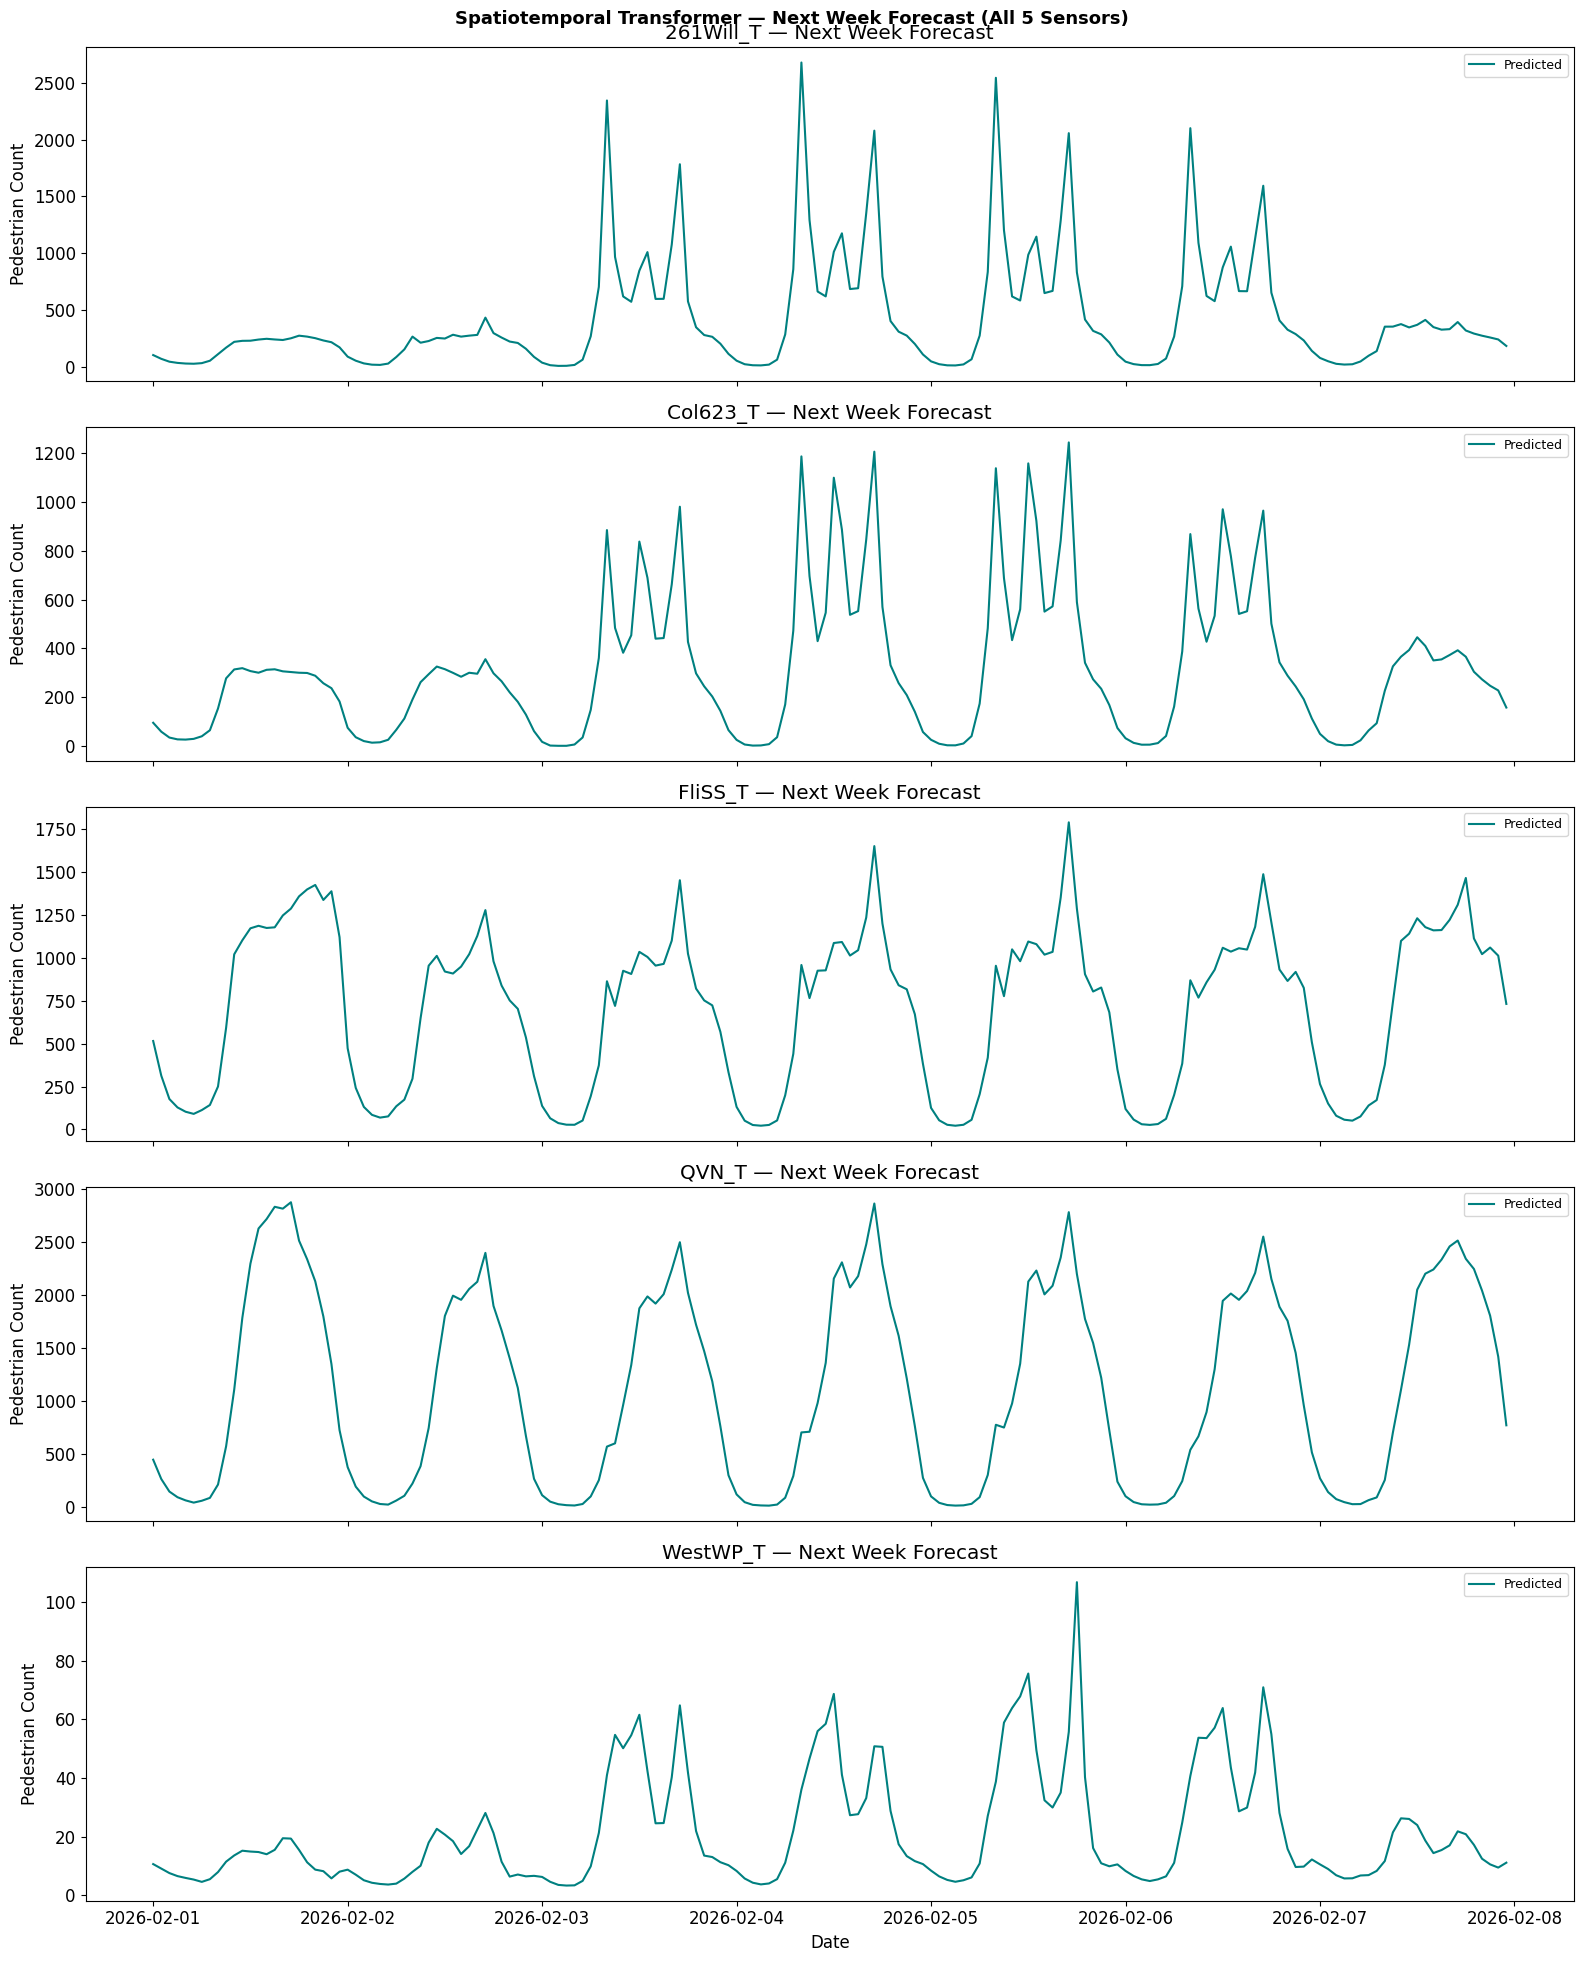

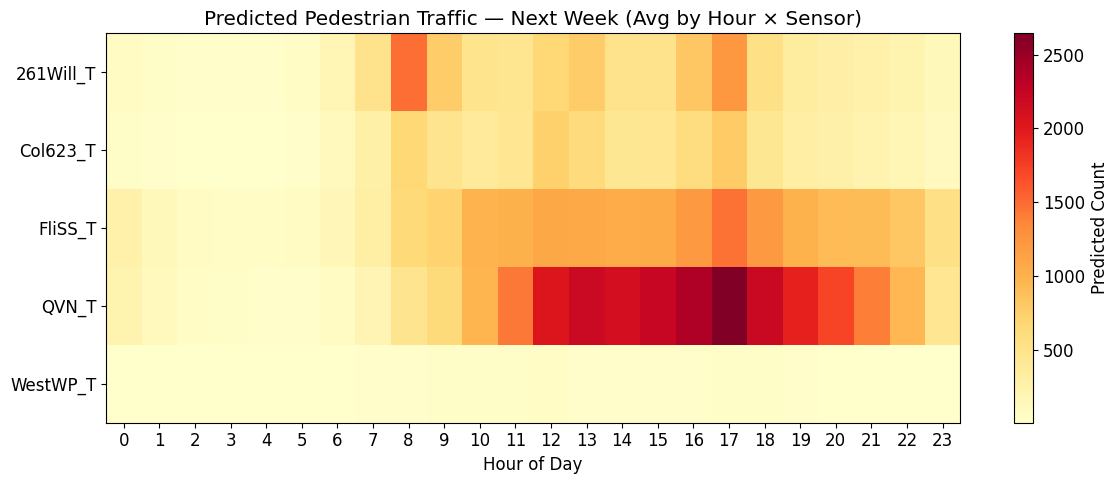

In [64]:
# ── Predict next week (real future) ──────────────────────────────────────────
# Use the very last SEQ_LEN_ST hours of the FULL dataset (including test period)
full_data   = pivot.values                          # all data, no split
full_scaled = net_scaler.transform(full_data)       # same scaler, no refit

input_future = (
    torch.tensor(full_scaled[-SEQ_LEN_ST:], dtype=torch.float32)
    .unsqueeze(0).to(DEVICE)
)

st_model.eval()
with torch.no_grad():
    future_scaled = st_model(input_future).squeeze(0).cpu().numpy()

future_pred = np.clip(net_scaler.inverse_transform(future_scaled), 0, None)

# ── Build future timestamps ───────────────────────────────────────────────────
last_ts      = pivot.index[-1]
future_index = pd.date_range(start=last_ts + pd.Timedelta(hours=1), periods=HORIZON_ST, freq='H')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(N_SENSORS_ST, 1, figsize=(16, 4*N_SENSORS_ST), sharex=True)
if N_SENSORS_ST == 1: axes = [axes]

for ax, (i, sensor) in zip(axes, enumerate(sensors_5)):
    ax.plot(future_index, future_pred[:, i], color='teal', linewidth=1.5, label='Predicted')
    ax.set_title(f'{sensor} — Next Week Forecast')
    ax.set_ylabel('Pedestrian Count')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('Spatiotemporal Transformer — Next Week Forecast (All 5 Sensors)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Heatmap: predicted counts (hour × sensor) ─────────────────────────────────
import matplotlib.pyplot as plt

heatmap_data = pd.DataFrame(future_pred, index=future_index, columns=sensors_5)
hourly_avg   = heatmap_data.groupby(heatmap_data.index.hour).mean()  # avg per hour across the week

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(hourly_avg.T, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(N_SENSORS_ST))
ax.set_yticklabels(sensors_5)
ax.set_xlabel('Hour of Day')
ax.set_title('Predicted Pedestrian Traffic — Next Week (Avg by Hour × Sensor)')
plt.colorbar(im, ax=ax, label='Predicted Count')
plt.tight_layout()
plt.show()

In [65]:
!pip install folium --quiet

import folium
import re

# ── Get coordinates for the 5 selected sensors ───────────────────────────────
coord_df = (
    raw[raw['Sensor_Name'].isin(sensors_5)][['Sensor_Name','Location']]
    .drop_duplicates('Sensor_Name')
    .set_index('Sensor_Name')
)

def parse_coords(loc_str):
    nums = re.findall(r'[-\d.]+', str(loc_str))
    return float(nums[0]), float(nums[1])

coords = {s: parse_coords(coord_df.loc[s, 'Location']) for s in sensors_5}

# ── Average predicted count per sensor across the forecast week ───────────────
avg_pred   = future_pred.mean(axis=0)
max_pred_f = float(avg_pred.max())

# ── Build Folium map centred on Melbourne CBD ─────────────────────────────────
m = folium.Map(location=[-37.814, 144.963], zoom_start=15, tiles='CartoDB positron')

for i, sensor in enumerate(sensors_5):
    lat, lon   = coords[sensor]
    intensity  = float(avg_pred[i])
    radius     = 20 + 60 * (intensity / max_pred_f)
    color      = f'#{int(255 * intensity/max_pred_f):02x}{int(255 * (1 - intensity/max_pred_f)):02x}00'

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{sensor}</b><br>Avg predicted: {intensity:.0f} pedestrians/hr",
            max_width=200
        ),
        tooltip=sensor
    ).add_to(m)

m

In [66]:
from folium.plugins import TimestampedGeoJson
import json

# ── Build GeoJSON features — one per sensor per hour ─────────────────────────
features = []

for hour_idx in range(HORIZON_ST):
    timestamp = future_index[hour_idx].strftime('%Y-%m-%dT%H:%M:%S')
    for i, sensor in enumerate(sensors_5):
        lat, lon  = coords[sensor]
        intensity = float(future_pred[hour_idx, i])
        radius    = 8 + 40 * (intensity / max_pred_f)
        # Normalise 0-1 for colour
        norm      = intensity / max_pred_f
        color     = f'#{int(255 * norm):02x}{int(255 * (1-norm)):02x}00'

        features.append({
            'type': 'Feature',
            'geometry': {
                'type': 'Point',
                'coordinates': [lon, lat]
            },
            'properties': {
                'time': timestamp,
                'popup': f'<b>{sensor}</b><br>{intensity:.0f} pedestrians/hr',
                'tooltip': sensor,
                'icon': 'circle',
                'iconstyle': {
                    'color': color,
                    'fillColor': color,
                    'fillOpacity': 0.7,
                    'radius': radius,
                    'weight': 2
                }
            }
        })

# ── Build animated map ────────────────────────────────────────────────────────
m2 = folium.Map(location=[-37.814, 144.963], zoom_start=15, tiles='CartoDB positron')

TimestampedGeoJson(
    data={'type': 'FeatureCollection', 'features': features},
    period='PT1H',
    duration='PT1H',
    auto_play=True,
    loop=True,
    max_speed=5,
    loop_button=True,
    time_slider_drag_update=True
).add_to(m2)

m2

   Actuals loaded: (168, 5)
   Missing hours: 2

=== Out-of-Sample Validation — Predicted vs February Actuals ===
   Sensor   MAE  RMSE  MAPE %  Hours
261Will_T 115.3 267.9   34.02    168
 Col623_T  81.5 158.6   30.63    168
  FliSS_T 218.0 282.0   55.24    168
    QVN_T 123.4 205.2   25.13    168
 WestWP_T   9.2  14.9   84.38    166

Network average MAE:    109.5
Network average RMSE:   185.7
Network average MAPE %: 45.88


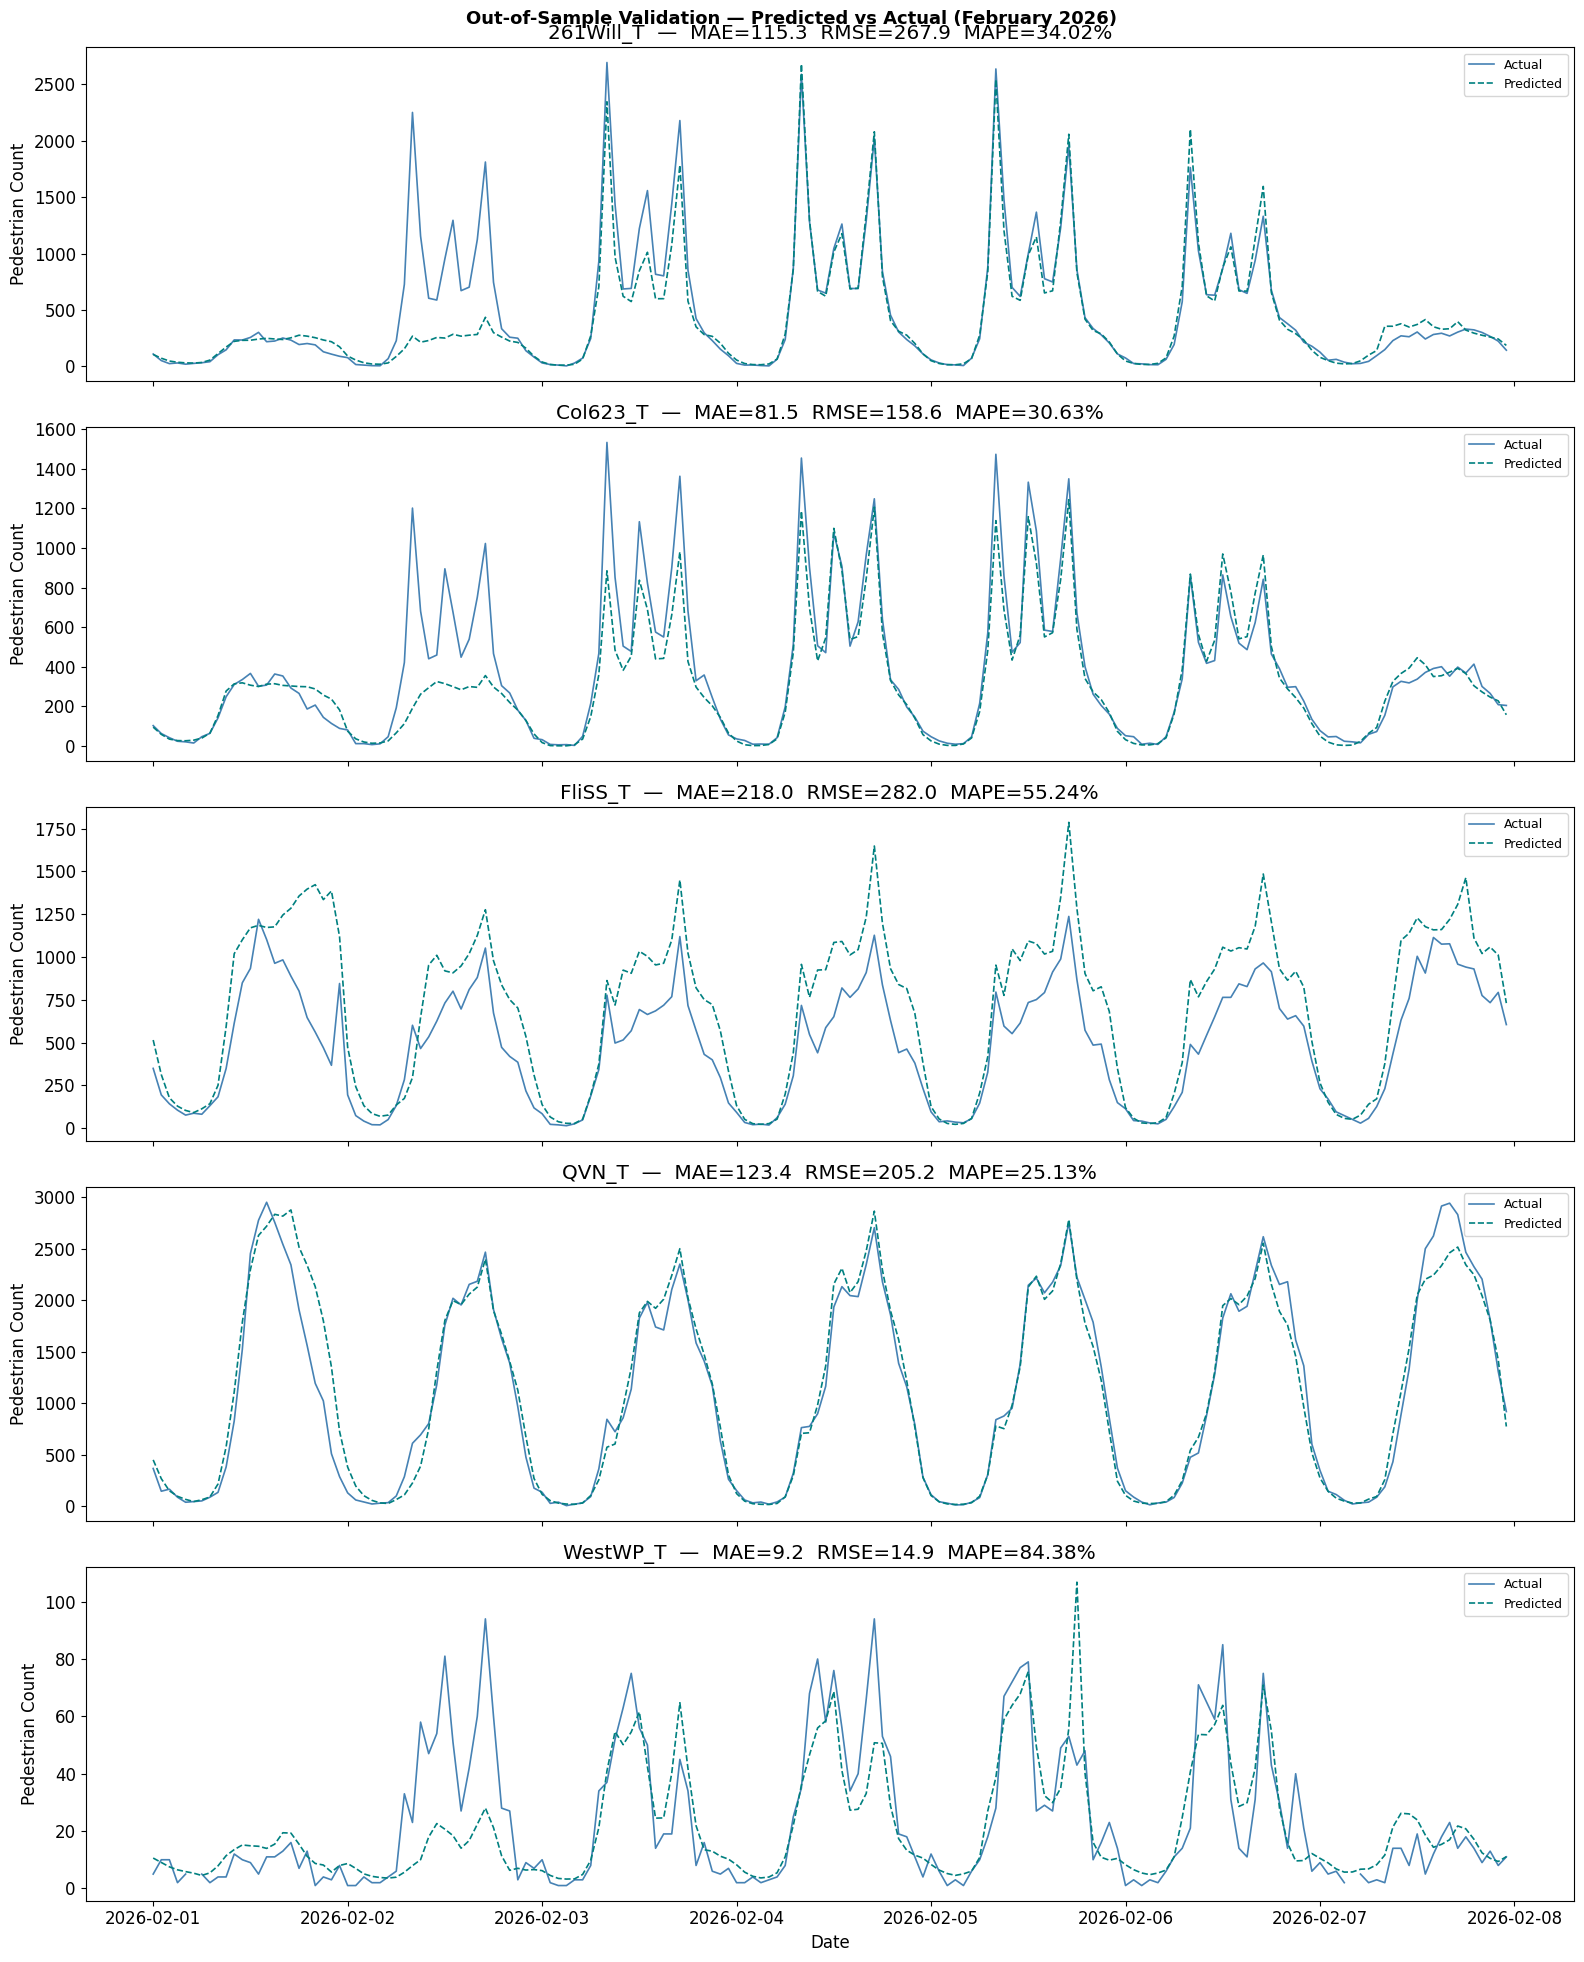

In [67]:
# ── Load actuals from Melbourne Open Data for the same period ─────────────────
feb_actuals = raw[
    (raw['ds'] >= future_index[0]) &
    (raw['ds'] <= future_index[-1]) &
    (raw['Sensor_Name'].isin(sensors_5))
][['ds', 'Sensor_Name', 'Total_of_Directions']].copy()

# Pivot to same format as predictions
feb_pivot = (
    feb_actuals
    .groupby(['ds', 'Sensor_Name'])['Total_of_Directions']
    .mean()
    .unstack('Sensor_Name')
    .reindex(future_index)
    [sensors_5]
)

print(f'   Actuals loaded: {feb_pivot.shape}')
print(f'   Missing hours: {feb_pivot.isnull().sum().sum()}')

# ── Metrics: predicted vs actual per sensor ───────────────────────────────────
validation_metrics = []
for i, sensor in enumerate(sensors_5):
    yt = feb_pivot[sensor].values
    yp = future_pred[:, i]
    mask = ~np.isnan(yt)
    if mask.sum() == 0:
        print(f'   No actuals found for {sensor} in this period')
        continue
    mae  = mean_absolute_error(yt[mask], yp[mask])
    rmse = np.sqrt(mean_squared_error(yt[mask], yp[mask]))
    mape = np.mean(np.abs((yt[mask] - yp[mask]) / np.where(yt[mask]==0, 1, yt[mask]))) * 100
    validation_metrics.append({'Sensor': sensor, 'MAE': round(mae,1), 'RMSE': round(rmse,1), 'MAPE %': round(mape,2), 'Hours': int(mask.sum())})

val_df = pd.DataFrame(validation_metrics)
print('\n=== Out-of-Sample Validation — Predicted vs February Actuals ===')
print(val_df.to_string(index=False))
print(f'\nNetwork average MAE:    {val_df["MAE"].mean():.1f}')
print(f'Network average RMSE:   {val_df["RMSE"].mean():.1f}')
print(f'Network average MAPE %: {val_df["MAPE %"].mean():.2f}')

# ── Plot predicted vs actual per sensor ───────────────────────────────────────
fig, axes = plt.subplots(N_SENSORS_ST, 1, figsize=(16, 4*N_SENSORS_ST), sharex=True)
if N_SENSORS_ST == 1: axes = [axes]

for ax, (i, sensor) in zip(axes, enumerate(sensors_5)):
    ax.plot(future_index, feb_pivot[sensor].values, label='Actual',    color='steelblue', linewidth=1.2)
    ax.plot(future_index, future_pred[:, i],        label='Predicted', color='teal',      linewidth=1.2, linestyle='--')
    row = val_df[val_df['Sensor']==sensor]
    if len(row):
        ax.set_title(f'{sensor}  —  MAE={row.iloc[0]["MAE"]}  RMSE={row.iloc[0]["RMSE"]}  MAPE={row.iloc[0]["MAPE %"]}%')
    ax.set_ylabel('Pedestrian Count')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('Out-of-Sample Validation — Predicted vs Actual (February 2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()